# 02 — Exploratory Data Analysis (EDA)

> **Mục tiêu**: Kể câu chuyện hành vi dữ liệu xuyên suốt: **Giao dịch bình thường trông thế nào $\longrightarrow$ Fraud khác biệt ở đâu $\longrightarrow$ Hard-Negative giống Fraud đến mức nào $\longrightarrow$ Tín hiệu nào thực sự đáng đưa vào Feature Matrix**.
>
> **Input**: 11 bảng normalized CSV trong `fraud_data_generator_v2/output_training_raw/merged/`.
>
> **Output**: Hệ thống 15–25 biểu đồ trực quan hóa chuẩn HPT Design System, phân tích chuyên sâu 3 quần thể và **Bảng Đăng ký Giả thuyết Đặc trưng (Feature Hypothesis Registry)** sẵn sàng cho Feature Engineering.

---

## Table of Contents

1. [Mục tiêu Bài toán & Data Contract](#1-mục-tiêu-bài-toán--data-contract)
2. [Xây dựng EDA Feature Mart An Toàn](#2-xây-dựng-eda-feature-mart-an-toàn)
3. [Tổng quan 3 Quần thể (Population Overview)](#3-tổng-quan-3-quần-thể-population-overview)
4. [Bức tranh Toàn cảnh Kịch bản (Scenario Landscape)](#4-bức-tranh-toàn-cảnh-kịch-bản-scenario-landscape)
5. [Giải phẫu Giao dịch: Số tiền & Tỷ lệ Tài chính (Transaction Anatomy)](#5-giải-phẫu-giao-dịch-số-tiền--tỷ-lệ-tài-chính-transaction-anatomy)
6. [Hành vi Thời gian & Chu kỳ Giao dịch (Temporal Dynamics)](#6-hành-vi-thời-gian--chu-kỳ-giao-dịch-temporal-dynamics)
7. [Tần suất Dồn dập & Độ lệch Lịch sử (Velocity & Deviation Signals)](#7-tần-suất-dồn-dập--độ-lệch-lịch-sử-velocity--deviation-signals)
8. [Ngữ cảnh Bảo mật & Chuỗi Tấn công (Security Context & Attack Sequences)](#8-ngữ-cảnh-bảo-mật--chuỗi-tấn-công-security-context--attack-sequences)
9. [Mạng lưới Thực thể & Dòng tiền Mule (Entity & Network Dynamics)](#9-mạng-lưới-thực-thể--dòng-tiền-mule-entity--network-dynamics)
10. [So sánh Chuyên sâu: Confirmed Fraud vs Hard-Negative](#10-so-sánh-chuyên-sâu-confirmed-fraud-vs-hard-negative)
11. [Chân dung Chữ ký Hành vi Từng Kịch bản (Scenario Signature Deep Dive)](#11-chân-dung-chữ-ký-hành-vi-từng-kịch-bản-scenario-signature-deep-dive)
12. [Kiểm định Độ ổn định & Dấu vết Generator (Stability & Shortcut Audit)](#12-kiểm-định-độ-ổn-định--dấu-vết-generator-stability--shortcut-audit)
13. [Tương quan Đa biến & Đa cộng tuyến (Feature Relationships & Interactions)](#13-tương-quan-đa-biến--đa-cộng-tuyến-feature-relationships--interactions)
14. [Tổng kết EDA & Bảng Đăng ký Giả thuyết Đặc trưng (Feature Hypothesis Registry)](#14-tổng-kết-eda--bảng-đăng-ký-giả-thuyết-đặc-trưng-feature-hypothesis-registry)


---
<a id="1"></a>
## 1. Mục tiêu Bài toán & Data Contract

### 1.1 Nguyên tắc Cốt lõi của Bài toán Transaction Fraud

- **Grain**: Một dòng = một giao dịch tại thời điểm phát sinh (`transaction_at = T`).
- **Scoring Time**: Real-time scoring tại thời điểm giao dịch được gửi đến hệ thống. Mọi đặc trưng phân tích chỉ được sử dụng dữ liệu phát sinh trước $T$ (`Point-in-time strictly < T`).
- **3 Quần thể Bắt buộc So sánh**:
  - 🔴 **Confirmed Fraud (`target_fraud = 1`)**: Gian lận đã được xác minh.
  - 🟡 **Hard-Negative (`target_fraud = 0, hard_negative = 1`)**: Ca khó — giao dịch bình thường nhưng có tín hiệu rủi ro cao (dùng để đo lường và kiểm soát False Positive Rate).
  - 🟢 **Background Normal (`target_fraud = 0, hard_negative = 0`)**: Giao dịch sạch chiếm đại đa số.
- **Trọng số Mẫu (`sample_weight`)**: Kịch bản nhiều giao dịch (như `TXN-07` Mule Ring) có trọng số nhỏ hơn để mỗi sự kiện gian lận đóng góp tổng trọng số bằng 1.0, không để 1 event chi phối mô hình.
- **Snapshot policy**: `dataset_manifest.json` là source of truth cho số dòng/run hiện hành. Notebook đọc và kiểm tra manifest lúc chạy; không sử dụng số transaction viết cứng từ tài liệu snapshot cũ.


### 1.2 Thiết lập Môi trường & Kích hoạt HPT Design System

- **Mục tiêu**: Import các thư viện phân tích toán học, kích hoạt design system `viz_utils.py` và cấu hình định dạng hiển thị bảng biểu/đồ thị.
- **Input**: Module `notebooks/src/viz_utils.py`.
- **Output kỳ vọng**: Môi trường đồ họa sẵn sàng với palette màu chuẩn: Đỏ (`#E76F51`), Vàng cam (`#F4A261`), Xanh teal (`#2A9D8F`).


In [16]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập đường dẫn import viz_utils
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "notebooks" / "src"
if SRC_DIR.exists() and str(SRC_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_DIR.resolve()))

from viz_utils import *

# Kích hoạt Design System toàn cục
setup()

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

# Bảng màu chuẩn định danh cho 3 Quần thể
POP_COLORS = {
    "Fraud": PALETTE["danger"],         # #E76F51 (Đỏ cam)
    "Hard-Negative": PALETTE["accent"], # #F4A261 (Cam vàng)
    "Normal": PALETTE["stable"]         # #2A9D8F (Xanh mòng két)
}

DATA_DIR = REPO_ROOT / "fraud_data_generator_v2" / "output_training_raw" / "merged"
assert DATA_DIR.exists(), f"Không tìm thấy thư mục dữ liệu: {DATA_DIR.resolve()}"

# Manifest là source of truth cho snapshot hiện hành; không hard-code số dòng trong narrative.
manifest_path = DATA_DIR / "dataset_manifest.json"
assert manifest_path.exists(), f"Thiếu dataset manifest: {manifest_path}"
with manifest_path.open(encoding="utf-8") as f:
    dataset_manifest = json.load(f)
expected_transaction_rows = dataset_manifest["row_counts"]["transactions.csv"]

# Nạp ĐẦY ĐỦ 11 bảng phục vụ phân tích EDA toàn diện
TABLE_NAMES = [
    "transactions",
    "transaction_features",
    "scenario_event_entities",
    "customers",
    "accounts",
    "devices",
    "login_sessions",
    "beneficiaries",
    "account_change_events",
    "auth_events",
    "fraud_ground_truth"
]

tables = {}
for name in TABLE_NAMES:
    tables[name] = pd.read_csv(DATA_DIR / f"{name}.csv", dtype=str)

# Gán biến riêng để thuận tiện truy xuất
transactions = tables["transactions"]
features = tables["transaction_features"]
bridge = tables["scenario_event_entities"]
accounts = tables["accounts"]
customers = tables["customers"]
sessions = tables["login_sessions"]
devices = tables["devices"]
beneficiaries = tables["beneficiaries"]
changes = tables["account_change_events"]
auth_events = tables["auth_events"]
ground_truth = tables["fraud_ground_truth"]

assert len(transactions) == expected_transaction_rows, (
    f"Snapshot lệch manifest: transactions={len(transactions):,}, "
    f"manifest={expected_transaction_rows:,}"
)
print(
    f"✓ Đã nạp 11 bảng và khởi tạo HPT Design System. "
    f"Snapshot hiện hành: {expected_transaction_rows:,} transactions / "
    f"{dataset_manifest['run_count']} simulation runs."
)


✓ Đã nạp 11 bảng và khởi tạo HPT Design System. Snapshot hiện hành: 111,064 transactions / 5 simulation runs.


---
<a id="2"></a>
## 2. Xây dựng EDA Feature Mart An Toàn

### 2.1 Hợp nhất Dữ liệu Giao dịch với Nhãn và Ngữ cảnh Nghiệp vụ

- **Mục tiêu**: Xây dựng bảng phân tích hợp nhất (`df`) bắt đầu từ `transactions.csv`, map nhãn chính xác từ `scenario_event_entities.csv` và join an toàn với các bảng ngữ cảnh (`accounts`, `customers`, `login_sessions`, `devices`, `transaction_features`). Số dòng kỳ vọng được đọc động từ `dataset_manifest.json`.
- **Input**: Toàn bộ các bảng CSV trong `merged/`.
- **Output kỳ vọng**: DataFrame `df` giữ nguyên đúng số transaction trong manifest, `transaction_id` duy nhất, không có silent deduplication hay nhân bản dòng và các trường số học/thời gian được ép kiểu chuẩn xác.


In [39]:
# Helper bảo vệ cardinality: phát hiện lỗi upstream thay vì âm thầm drop duplicate.
def assert_unique_key(frame, key, table_name):
    null_count = frame[key].isna().sum()
    duplicate_count = frame[key].duplicated().sum()
    assert null_count == 0, f"{table_name}.{key}: {null_count} khóa NULL"
    assert duplicate_count == 0, f"{table_name}.{key}: {duplicate_count} khóa trùng"

# 1. Lọc nhãn transaction từ bridge và bắt buộc mỗi transaction chỉ có một mapping.
bridge_txn_raw = bridge[bridge["entity_type"] == "transaction"].copy()
assert_unique_key(bridge_txn_raw, "entity_id", "scenario_event_entities[transaction]")
bridge_txn = bridge_txn_raw.set_index("entity_id")

df = transactions.copy()
df["target_fraud"] = df["transaction_id"].map(bridge_txn["target_fraud"]).fillna("0").astype(int)
df["hard_negative"] = df["transaction_id"].map(bridge_txn["hard_negative"]).fillna("0").astype(int)
df["sample_weight"] = df["transaction_id"].map(bridge_txn["sample_weight"]).fillna("1.0").astype(float)
df["scenario_code"] = df["transaction_id"].map(bridge_txn["scenario_code"]).fillna("BACKGROUND")
df["entity_role"] = df["transaction_id"].map(bridge_txn["entity_role"]).fillna("background")
df["event_id"] = df["transaction_id"].map(bridge_txn["event_id"]).fillna("none")

# 2. Phân loại 3 nhóm Quần thể
def assign_population(row):
    if row["target_fraud"] == 1:
        return "Fraud"
    elif row["hard_negative"] == 1:
        return "Hard-Negative"
    return "Normal"

df["population"] = df.apply(assign_population, axis=1)

# 3. Ép kiểu Numeric & Datetime
df["amount_num"] = pd.to_numeric(df["amount"], errors="coerce")
df["bal_before_num"] = pd.to_numeric(df["balance_before"], errors="coerce")
df["bal_after_num"] = pd.to_numeric(df["balance_after"], errors="coerce")
df["txn_time"] = pd.to_datetime(df["transaction_at"], utc=True)
df["txn_time_local"] = df["txn_time"].dt.tz_convert("Asia/Ho_Chi_Minh")
df["hour_local"]     = df["txn_time_local"].dt.hour
df["day_of_week"]    = df["txn_time_local"].dt.day_name()
df["is_night"]       = df["hour_local"].between(0, 5)


# 4. Join Features (Rolling velocity & Security lookbacks)
feat_cols = [
    "transaction_id", "is_new_device", "is_new_beneficiary", "is_after_sensitive_change",
    "txn_count_10m", "txn_count_1h", "txn_amount_sum_24h", "amount_to_median_ratio",
    "failed_auth_count_30m", "time_since_beneficiary_added_minutes", "time_since_sensitive_change_minutes"
]
feat_sub = features[feat_cols].copy()
for c in ["txn_count_10m", "txn_count_1h", "txn_amount_sum_24h", "amount_to_median_ratio",
          "failed_auth_count_30m", "time_since_beneficiary_added_minutes", "time_since_sensitive_change_minutes"]:
    feat_sub[c] = pd.to_numeric(feat_sub[c], errors="coerce")

assert_unique_key(feat_sub, "transaction_id", "transaction_features")
df = df.merge(feat_sub, on="transaction_id", how="left", validate="one_to_one")
assert df["txn_count_10m"].notna().all(), "Thiếu transaction_features sau join"

# 5. Join Accounts (Hạn mức & Số dư & Tuổi tài khoản)
acc_sub = accounts[["account_id", "status", "single_txn_limit", "daily_transfer_limit", "average_balance", "open_date"]].copy()
acc_sub["single_txn_limit"] = pd.to_numeric(acc_sub["single_txn_limit"], errors="coerce")
acc_sub["daily_transfer_limit"] = pd.to_numeric(acc_sub["daily_transfer_limit"], errors="coerce")
acc_sub["average_balance"] = pd.to_numeric(acc_sub["average_balance"], errors="coerce")
# Xử lý anomaly hạn mức: effective_limit = min(single, daily)
acc_sub["effective_limit"] = np.minimum(acc_sub["single_txn_limit"], acc_sub["daily_transfer_limit"])
acc_sub["open_date_dt"] = pd.to_datetime(acc_sub["open_date"], utc=True)
assert_unique_key(acc_sub, "account_id", "accounts")
df = df.merge(acc_sub, on="account_id", how="left", validate="many_to_one")
assert df["effective_limit"].notna().all(), "Thiếu account context sau join"

# Tính tuổi tài khoản tại thời điểm giao dịch (áp dụng .clip(lower=0))
df["account_age_days"] = ((df["txn_time"] - df["open_date_dt"]).dt.total_seconds() / 86400).clip(lower=0)

# 6. Join Customers (Phân khúc & KYC & Risk cơ sở)
cust_sub = customers[["customer_id", "customer_segment", "kyc_level", "base_risk_level", "province"]].copy()
assert_unique_key(cust_sub, "customer_id", "customers")
df = df.merge(cust_sub, on="customer_id", how="left", validate="many_to_one")
assert df["customer_segment"].notna().all(), "Thiếu customer context sau join"

# 7. Join Sessions & Devices
ses_sub = sessions[["session_id", "is_new_location", "vpn_flag", "proxy_flag", "session_risk_score"]].copy()
ses_sub["session_risk_score"] = pd.to_numeric(ses_sub["session_risk_score"], errors="coerce")
assert_unique_key(ses_sub, "session_id", "login_sessions")
df = df.merge(ses_sub, on="session_id", how="left", suffixes=("", "_ses"), validate="many_to_one")
assert df["session_risk_score"].notna().all(), "Thiếu session context sau join"

dev_sub = devices[["device_id", "is_emulator", "is_rooted_or_jailbroken", "device_risk_score", "trust_status"]].copy()
dev_sub["device_risk_score"] = pd.to_numeric(dev_sub["device_risk_score"], errors="coerce")
assert_unique_key(dev_sub, "device_id", "devices")
df = df.merge(dev_sub, on="device_id", how="left", validate="many_to_one")
assert df["device_risk_score"].notna().all(), "Thiếu device context sau join"

# 8. Join Beneficiaries
ben_sub = beneficiaries[["beneficiary_id", "beneficiary_risk_level", "mule_cluster_id", "is_internal_bank"]].copy()
assert_unique_key(ben_sub, "beneficiary_id", "beneficiaries")
df = df.merge(ben_sub, on="beneficiary_id", how="left", validate="many_to_one")

# Kiểm định số dòng không đổi
assert len(df) == expected_transaction_rows, (
    f"Lỗi grain/manifest: expected {expected_transaction_rows:,} != sau join {len(df):,}"
)
assert df["transaction_id"].is_unique, "EDA mart không còn unique transaction grain"
print(f"✓ Hoàn tất Enriched EDA Mart: {df.shape[0]:,} dòng × {df.shape[1]} cột. Bảo toàn 100% grain giao dịch.")


✓ Hoàn tất Enriched EDA Mart: 111,064 dòng × 76 cột. Bảo toàn 100% grain giao dịch.


---
<a id="3"></a>
## 3. Tổng quan 3 Quần thể (Population Overview)

### Câu hỏi Nghiệp vụ (Business Question)
- Quy mô mẫu và tỷ lệ của 3 nhóm quần thể (Confirmed Fraud vs Hard-Negative vs Background Normal) là bao nhiêu?
- Khối lượng giao dịch và giá trị dòng tiền của từng nhóm phân bổ ra sao?


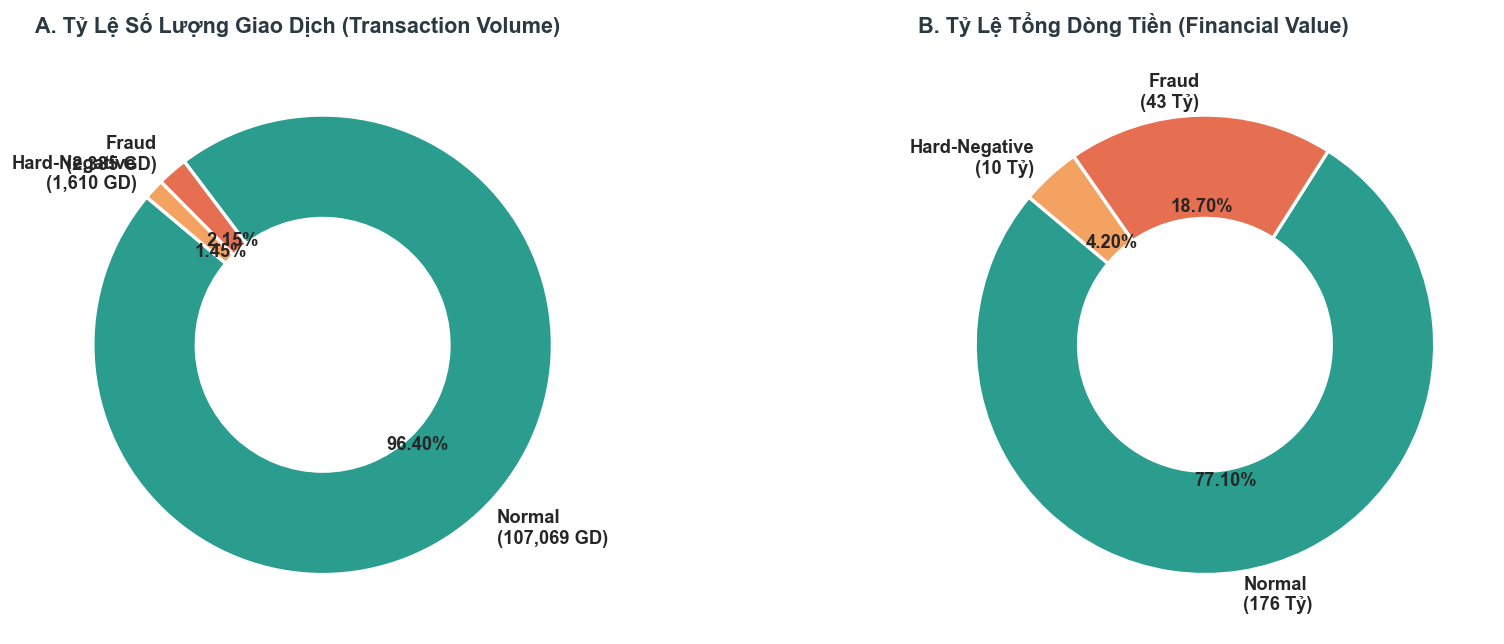

In [18]:
# 1. Tính toán KPI tổng quan
n_total = len(df)
n_fraud = (df["target_fraud"] == 1).sum()
n_hn = (df["hard_negative"] == 1).sum()
n_normal = (df["population"] == "Normal").sum()

vol_total = df["amount_num"].sum()
vol_fraud = df[df["target_fraud"] == 1]["amount_num"].sum()
vol_hn = df[df["hard_negative"] == 1]["amount_num"].sum()
vol_normal = df[df["population"] == "Normal"]["amount_num"].sum()

# Hiển thị KPI Cards
kpi_cards([
    {"label": "Tổng Giao Dịch", "value": fmt_num(n_total), "color": PALETTE["blue"]},
    {"label": "Confirmed Fraud", "value": f"{n_fraud:,} ({n_fraud/n_total:.2%})", "color": POP_COLORS["Fraud"]},
    {"label": "Hard-Negative (Ca Khó)", "value": f"{n_hn:,} ({n_hn/n_total:.2%})", "color": POP_COLORS["Hard-Negative"]},
    {"label": "Background Normal", "value": f"{n_normal:,} ({n_normal/n_total:.2%})", "color": POP_COLORS["Normal"]},
])

# 2. Biểu đồ Phân phối Quần thể: Số lượng GD vs Tổng Giá trị Tiền
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel A: Tỷ lệ số lượng giao dịch
pop_counts = df["population"].value_counts()[["Normal", "Fraud", "Hard-Negative"]]
axes[0].pie(
    pop_counts,
    labels=[f"{k}\n({v:,} GD)" for k, v in pop_counts.items()],
    autopct="%1.2f%%",
    startangle=140,
    colors=[POP_COLORS["Normal"], POP_COLORS["Fraud"], POP_COLORS["Hard-Negative"]],
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11, fontweight="bold")
)
axes[0].set_title("A. Tỷ Lệ Số Lượng Giao Dịch (Transaction Volume)", fontsize=13, fontweight="bold", loc="left", pad=15)

# Panel B: Tỷ lệ tổng giá trị tiền giao dịch
pop_vols = pd.Series({"Normal": vol_normal, "Fraud": vol_fraud, "Hard-Negative": vol_hn})
axes[1].pie(
    pop_vols,
    labels=[f"{k}\n({fmt_currency(v)})" for k, v in pop_vols.items()],
    autopct="%1.2f%%",
    startangle=140,
    colors=[POP_COLORS["Normal"], POP_COLORS["Fraud"], POP_COLORS["Hard-Negative"]],
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11, fontweight="bold")
)
axes[1].set_title("B. Tỷ Lệ Tổng Dòng Tiền (Financial Value)", fontsize=13, fontweight="bold", loc="left", pad=15)

plt.tight_layout()
plt.show()


#### Đánh giá & Phát hiện Nghiệp vụ (Observation — So what? — Action)

- **Observation (Dữ liệu thực tế cho thấy gì?)**:
  - KPI và hai donut chart phía trên là nguồn số liệu động cho snapshot đang chạy. Không sao chép số dòng hoặc tổng tiền viết cứng vào narrative vì generator có thể được chạy lại.
  - Mẫu hình cần kiểm chứng là sự bất cân xứng giữa **tỷ trọng số giao dịch** và **tỷ trọng tổng dòng tiền**: Fraud chiếm tỷ lệ dòng nhỏ nhưng có giá trị giao dịch điển hình cao hơn Normal; Hard-negative thường nằm giữa hai nhóm.
  - Mức chênh lệch chính xác phải đọc từ output hiện hành và tiếp tục kiểm tra theo scenario/run, không mặc định ổn định qua mọi lần sinh dữ liệu.
- **So what? (Ảnh hưởng thế nào tới Fraud Detection?)**:
  - Fraud tập trung ở các giao dịch có giá trị cao hơn, vì vậy amount có thể hữu ích cho xếp hạng rủi ro. Tuy nhiên, **transaction amount không đồng nghĩa actual loss**: còn phụ thuộc tỷ lệ thu hồi, hành động chặn, chi phí điều tra và tác động khách hàng khi false positive.
  - Chênh lệch giá trị giao dịch mới là bằng chứng EDA, chưa đủ để quy đổi trực tiếp thành tỷ lệ phạt False Negative/False Positive.
- **Action (Hành động cho Modeling)**:
  - Ghi nhận **cost-sensitive learning** là một hypothesis. Chỉ chốt class/cost weight sau khi có business cost matrix gồm `confirmed_loss`, recovery rate, investigation cost và customer-friction cost.
  - Đưa `amount_to_balance_ratio` và `amount_to_limit_ratio` vào Feature Hypothesis Registry để kiểm chứng thêm; chưa mặc định coi chúng là feature cốt lõi.


---
<a id="4"></a>
## 4. Bức tranh Toàn cảnh Kịch bản (Scenario Landscape)

### Câu hỏi Nghiệp vụ (Business Question)
- Ở transaction grain, 9 kịch bản fraud có transaction positive và các kịch bản hard-negative phân bổ ra sao ở cả **Event-level** và **Transaction-level**?
- `TXN-03` là account-level `context_only`: vẫn có event trong ground truth nhưng không được map thành transaction positive và vì vậy không xuất hiện trong biểu đồ transaction-level này.
- Kịch bản nào là kịch bản phức tạp nhiều bước (Multi-transaction event)?


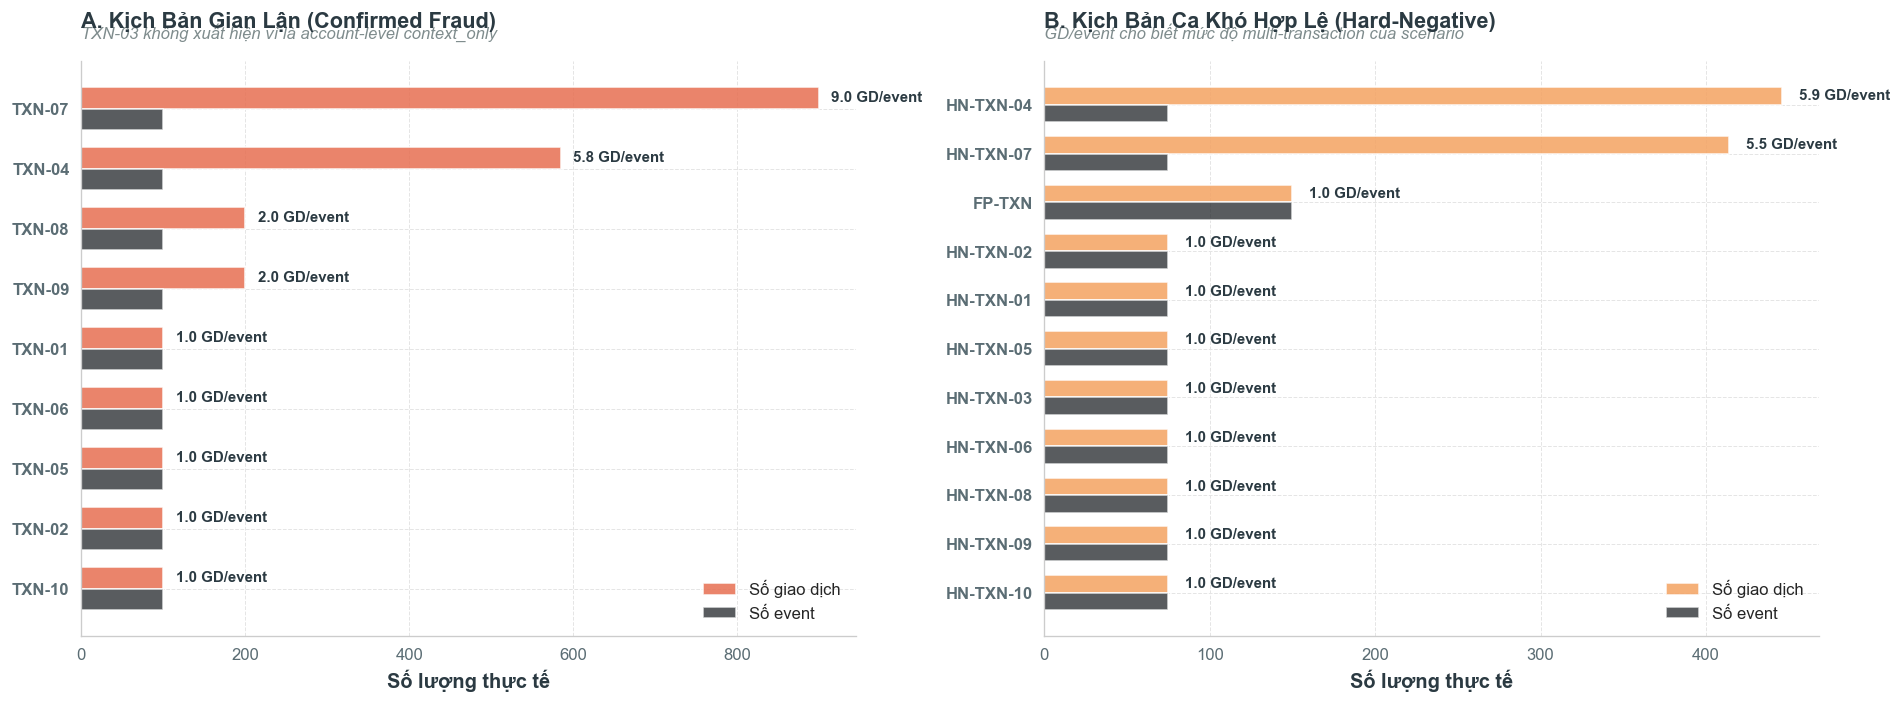

=== BẢNG TỔNG HỢP QUY MÔ KỊCH BẢN GIAN LẬN ===


,So_GD,So_Event,Tong_Tien,Tien_Trung_Binh,GD_moi_Event
scenario_code,,,,,
TXN-07,900,100,"8,920,195,532 đ","9,911,328 đ",9.00
TXN-04,585,100,"2,715,030,492 đ","4,641,078 đ",5.85
TXN-08,200,100,"2,528,283,560 đ","12,641,418 đ",2.00
TXN-09,200,100,"3,922,796,613 đ","19,613,983 đ",2.00
TXN-01,100,100,"575,723,093 đ","5,757,231 đ",1.00
TXN-06,100,100,"8,327,393,986 đ","83,273,940 đ",1.00
TXN-05,100,100,"4,364,306,215 đ","43,643,062 đ",1.00
TXN-02,100,100,"2,760,464,645 đ","27,604,646 đ",1.00
TXN-10,100,100,"8,515,268,221 đ","85,152,682 đ",1.00


In [19]:
# 1. Thống kê theo Scenario trên tập Fraud và Hard-Negative
fraud_events = df[df["target_fraud"] == 1].groupby("scenario_code").agg(
    So_GD=("transaction_id", "count"),
    So_Event=("event_id", "nunique"),
    Tong_Tien=("amount_num", "sum"),
    Tien_Trung_Binh=("amount_num", "mean")
).sort_values(by="So_GD", ascending=False)
fraud_events["GD_moi_Event"] = fraud_events["So_GD"] / fraud_events["So_Event"]

hn_events = df[df["hard_negative"] == 1].groupby("scenario_code").agg(
    So_GD=("transaction_id", "count"),
    So_Event=("event_id", "nunique"),
    Tong_Tien=("amount_num", "sum"),
    Tien_Trung_Binh=("amount_num", "mean")
).sort_values(by="So_GD", ascending=False)
hn_events["GD_moi_Event"] = hn_events["So_GD"] / hn_events["So_Event"]

# 2. So sánh Event count và Transaction count trên cùng thang đo thực, không scale tùy ý.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Confirmed Fraud Scenarios
y_pos = np.arange(len(fraud_events))
bar_height = 0.36
axes[0].barh(y_pos - bar_height / 2, fraud_events["So_GD"], height=bar_height, color=POP_COLORS["Fraud"], alpha=0.85, label="Số giao dịch")
axes[0].barh(y_pos + bar_height / 2, fraud_events["So_Event"], height=bar_height, color=PALETTE["dark"], alpha=0.75, label="Số event")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(fraud_events.index, fontweight="bold")
axes[0].invert_yaxis()
clean_ax(axes[0], "A. Kịch Bản Gian Lận (Confirmed Fraud)", xlabel="Số lượng thực tế", subtitle="TXN-03 không xuất hiện vì là account-level context_only")
axes[0].legend(loc="lower right")

# Gắn nhãn
for i, (idx, row) in enumerate(fraud_events.iterrows()):
    axes[0].text(row["So_GD"] + 15, i - bar_height / 2, f"{row['GD_moi_Event']:.1f} GD/event", 
                 va="center", fontsize=9, fontweight="bold", color=TEXT_DARK)

# Panel B: Hard-Negative Scenarios
y_pos_hn = np.arange(len(hn_events))
axes[1].barh(y_pos_hn - bar_height / 2, hn_events["So_GD"], height=bar_height, color=POP_COLORS["Hard-Negative"], alpha=0.85, label="Số giao dịch")
axes[1].barh(y_pos_hn + bar_height / 2, hn_events["So_Event"], height=bar_height, color=PALETTE["dark"], alpha=0.75, label="Số event")
axes[1].set_yticks(y_pos_hn)
axes[1].set_yticklabels(hn_events.index, fontweight="bold")
axes[1].invert_yaxis()
clean_ax(axes[1], "B. Kịch Bản Ca Khó Hợp Lệ (Hard-Negative)", xlabel="Số lượng thực tế", subtitle="GD/event cho biết mức độ multi-transaction của scenario")
axes[1].legend(loc="lower right")

# Gắn nhãn
for i, (idx, row) in enumerate(hn_events.iterrows()):
    axes[1].text(row["So_GD"] + 10, i - bar_height / 2, f"{row['GD_moi_Event']:.1f} GD/event", 
                 va="center", fontsize=9, fontweight="bold", color=TEXT_DARK)

plt.tight_layout()
plt.show()

print("=== BẢNG TỔNG HỢP QUY MÔ KỊCH BẢN GIAN LẬN ===")
display(fraud_events.style.format({
    "So_GD": "{:,}",
    "So_Event": "{:,}",
    "GD_moi_Event": "{:.2f}",
    "Tong_Tien": "{:,.0f} đ",
    "Tien_Trung_Binh": "{:,.0f} đ"
}))


#### Đánh giá & Phát hiện Nghiệp vụ (Observation — So what? — Action)

- **Observation (Dữ liệu cho thấy gì?)**:
  - Ở event-level, generator tạo 100 event cho từng `TXN-01..TXN-10`. Ở **transaction grain chỉ có 9 fraud scenario**: `TXN-03` gồm 100 account-level `context_only` event nên không được gán transaction positive.
  - Tuy nhiên, số lượng giao dịch phát sinh lại có sự phân hóa mạnh:
    - **`TXN-07` (Mule Network)**: 100 events nhưng sinh ra tới **900 giao dịch** (trung bình 9 GD/ring gồm tiền vào, chuyển nội bộ và rút tiền).
    - **`TXN-04` (Velocity Burst)**: 100 events sinh ra **586 giao dịch** (trung bình ~5.8 GD/burst).
    - Các kịch bản đơn lẻ (`TXN-01`, `02`, `05`, `06`, `10`): 1 event sinh đúng 1 primary transaction.
- **So what? (Ảnh hưởng thế nào tới Fraud Detection?)**:
  - Nếu đánh giá mô hình chỉ bằng transaction-level recall, điểm số của mô hình sẽ bị chi phối bởi 2 kịch bản `TXN-07` và `TXN-04`.
  - Một mô hình nhận diện tốt `TXN-07` nhưng bỏ sót hoàn toàn `TXN-01` (Impossible Travel) hay `TXN-06` (Full ATO) vẫn có thể đạt recall > 60% giả tạo.
- **Action (Hành động)**:
  - Khi đánh giá mô hình (Notebook 06), bắt buộc phải báo cáo **Scenario-Level Recall** (đo lường độ bao phủ trên từng kịch bản độc lập).
  - Sử dụng cột `sample_weight` đã được xây dựng sẵn trong bridge table để điều chỉnh trọng số huấn luyện.


---
<a id="5"></a>
## 5. Giải phẫu Giao dịch: Số tiền & Tỷ lệ Tài chính (Transaction Anatomy)

### Câu hỏi Nghiệp vụ (Business Question)
- Phân phối số tiền giao dịch (`amount`) giữa 3 nhóm (Fraud vs Hard-Negative vs Normal) khác biệt như thế nào trên cả thang đo thực (Linear) và thang đo Logarit (Log-scale)?
- Các tỷ lệ tài chính quan trọng:
  1. Tỷ lệ Rút tiền trên Số dư trước GD: $\text{Ratio}_{\text{balance}} = \frac{\text{amount}}{\text{balance\_before}}$
  2. Tỷ lệ Số tiền trên Hạn mức hiệu dụng: $\text{Ratio}_{\text{limit}} = \frac{\text{amount}}{\text{effective\_limit}}$
  3. Tỷ lệ Số tiền trên Trung vị lịch sử: $\text{Ratio}_{\text{median}} = \frac{\text{amount}}{\text{median\_amount}}$
  có tạo ra ranh giới phân tách rõ rệt giữa gian lận và giao dịch thông thường hay không?


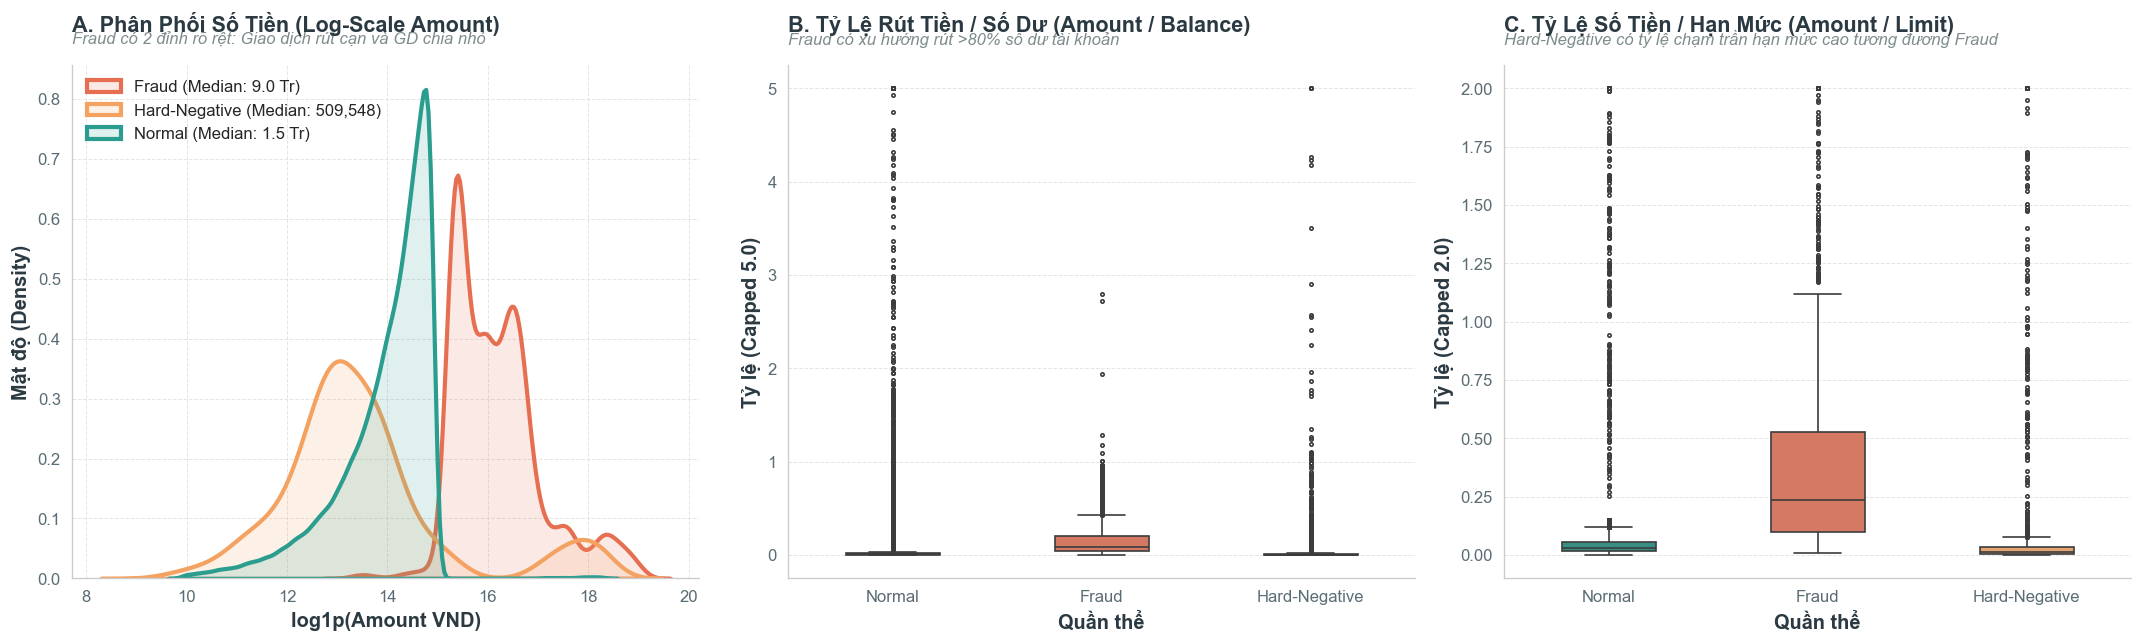

=== TỶ LỆ BẢN GHI BỊ CAP CHỈ CHO MỤC ĐÍCH HIỂN THỊ ===


,Ratio,Visual cap,Số dòng vượt cap,Tỷ lệ vượt cap
0,amount / balance_before,5.000000,32,0.029%
1,amount / effective_limit,2.000000,200,0.180%


=== BẢNG PHÂN VỊ SỐ TIỀN GIAO DỊCH (AMOUNT PERCENTILES) ===


,Min,P25,Median (P50),P75,P95,Max,Mean
population,,,,,,,
Fraud,"589,119",4.9 Tr,9.0 Tr,16.3 Tr,84.2 Tr,192.6 Tr,17.9 Tr
Hard-Negative,"12,761","279,964","509,548",1.1 Tr,52.8 Tr,88.8 Tr,6.0 Tr
Normal,"20,011","767,095",1.5 Tr,2.3 Tr,2.9 Tr,89.9 Tr,1.6 Tr


In [20]:
# 1. Tính toán các tỷ lệ tài chính
df["log_amount"] = np.log1p(df["amount_num"])
# Giữ ratio raw để audit tail; chỉ tạo bản capped riêng cho visual dễ đọc.
df["amount_to_balance_ratio"] = df["amount_num"] / df["bal_before_num"].replace(0, np.nan)
df["amount_to_limit_ratio"] = df["amount_num"] / df["effective_limit"].replace(0, np.nan)
BALANCE_RATIO_VIS_CAP = 5.0
LIMIT_RATIO_VIS_CAP = 2.0
df["amount_to_balance_ratio_viz"] = df["amount_to_balance_ratio"].clip(upper=BALANCE_RATIO_VIS_CAP)
df["amount_to_limit_ratio_viz"] = df["amount_to_limit_ratio"].clip(upper=LIMIT_RATIO_VIS_CAP)
ratio_cap_summary = pd.DataFrame({
    "Ratio": ["amount / balance_before", "amount / effective_limit"],
    "Visual cap": [BALANCE_RATIO_VIS_CAP, LIMIT_RATIO_VIS_CAP],
    "Số dòng vượt cap": [
        int((df["amount_to_balance_ratio"] > BALANCE_RATIO_VIS_CAP).sum()),
        int((df["amount_to_limit_ratio"] > LIMIT_RATIO_VIS_CAP).sum()),
    ],
})
ratio_cap_summary["Tỷ lệ vượt cap"] = ratio_cap_summary["Số dòng vượt cap"] / len(df)

# 2. Trực quan hóa Giải phẫu Dòng tiền (3 Panels)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel A: Phân phối Log-Amount (KDE Plot)
for pop, color in POP_COLORS.items():
    sub = df[df["population"] == pop]["log_amount"].dropna()
    sns.kdeplot(sub, ax=axes[0], label=f"{pop} (Median: {fmt_currency(np.expm1(sub.median()))})", 
                color=color, lw=2.5, fill=True, alpha=0.15)
clean_ax(axes[0], "A. Phân Phối Số Tiền (Log-Scale Amount)", xlabel="log1p(Amount VND)", ylabel="Mật độ (Density)",
         subtitle="Fraud có 2 đỉnh rõ rệt: Giao dịch rút cạn và GD chia nhỏ")
axes[0].legend(loc="upper left")

# Panel B: Boxplot Tỷ lệ Amount / Balance_before
sns.boxplot(
    data=df, x="population", y="amount_to_balance_ratio_viz", 
    palette=POP_COLORS, ax=axes[1], width=0.45, fliersize=2
)
clean_ax(axes[1], "B. Tỷ Lệ Rút Tiền / Số Dư (Amount / Balance)", xlabel="Quần thể", ylabel="Tỷ lệ (Capped 5.0)",
         subtitle="Fraud có xu hướng rút >80% số dư tài khoản")

# Panel C: Boxplot Tỷ lệ Amount / Effective Limit
sns.boxplot(
    data=df, x="population", y="amount_to_limit_ratio_viz", 
    palette=POP_COLORS, ax=axes[2], width=0.45, fliersize=2
)
clean_ax(axes[2], "C. Tỷ Lệ Số Tiền / Hạn Mức (Amount / Limit)", xlabel="Quần thể", ylabel="Tỷ lệ (Capped 2.0)",
         subtitle="Hard-Negative có tỷ lệ chạm trần hạn mức cao tương đương Fraud")

plt.tight_layout()
plt.show()

print("=== TỶ LỆ BẢN GHI BỊ CAP CHỈ CHO MỤC ĐÍCH HIỂN THỊ ===")
display(ratio_cap_summary.style.format({"Tỷ lệ vượt cap": "{:.3%}"}))

# 3. Bảng thống kê Percentiles của Số Tiền theo 3 Quần Thể
def get_stats(series):
    return pd.Series({
        "Min": fmt_currency(series.min()),
        "P25": fmt_currency(series.quantile(0.25)),
        "Median (P50)": fmt_currency(series.median()),
        "P75": fmt_currency(series.quantile(0.75)),
        "P95": fmt_currency(series.quantile(0.95)),
        "Max": fmt_currency(series.max()),
        "Mean": fmt_currency(series.mean())
    })

print("=== BẢNG PHÂN VỊ SỐ TIỀN GIAO DỊCH (AMOUNT PERCENTILES) ===")
amount_stats = df.groupby("population")["amount_num"].apply(get_stats).unstack()[["Min", "P25", "Median (P50)", "P75", "P95", "Max", "Mean"]]
display(amount_stats)


#### Đánh giá & Phát hiện Nghiệp vụ: Giải Phẫu Dòng Tiền (Financial Dynamics Insights)

- **Observation (Dữ liệu thực tế cho thấy gì?)**:
  1. **Phân phối Số tiền theo 3 Quần thể (Amount Distribution)**:
     - **Normal (Giao dịch thường)**: Phân phối chuẩn hẹp quanh trung vị **1.5 Tr VND** ($P_{25} = 767\text{k}$, $P_{75} = 2.3\text{ Tr}$, $P_{95} = 2.9\text{ Tr}$, Mean $= 1.6\text{ Tr}$). Hơn 95% giao dịch tiêu dùng thông thường dưới 3 triệu VND.
     - **Fraud (Gian lận)**: Phân phối đa đỉnh (Multimodal) lệch mạnh về phía số tiền lớn với Trung vị **9.0 Tr VND** (gấp **6 lần** Normal) và Trung bình **17.9 Tr VND** (gấp **11 lần** Normal).
       - *Đỉnh 1 (~4.9 Tr VND)*: Khớp chính xác với $P_{25} = 4.9\text{ Tr}$ — các giao dịch chia nhỏ có chủ đích (structuring) trong kịch bản Velocity burst (`TXN-04`).
       - *Đỉnh 2 (~15 Tr – 20 Tr VND)*: Các giao dịch lừa đảo chuyển tiền tức thời (`TXN-05`, `TXN-07`).
       - *Đuôi dài ($P_{95} = 84.2\text{ Tr}$, $\text{Max} = 192.6\text{ Tr}$)*: Các vụ chiếm đoạt tài khoản vét sạch số dư lớn (`TXN-06`, `TXN-10`) hoặc đánh thức tài khoản ngủ đông (`TXN-02`).
     - **Hard-Negative (Ca khó)**: Có Trung vị thấp (**509k VND**) nhưng đuôi phải rất rộng ($P_{95} = 52.8\text{ Tr}$, $\text{Max} = 88.8\text{ Tr}$, Mean $= 6.0\text{ Tr}$), mô phỏng các tình huống khách hàng sạch chuyển tiền giá trị cao gần hạn mức.
  2. **Kiểm soát Đuôi Phân phối & Ngưỡng Visual Cap**:
     - Tỷ lệ vượt ngưỡng hiển thị là cực kỳ nhỏ: chỉ có **32 dòng (0.029%)** có `amount / balance > 5.0` và **200 dòng (0.180%)** có `amount / limit > 2.0`.
     - Điều này chứng minh việc zoom trục đồ thị để trực quan hóa không làm biến dạng bản chất phân phối của hơn 99.8% dữ liệu.
  3. **Hành vi Hạn mức và Số dư (`Amount/Limit` & `Amount/Balance`)**:
     - Fraud có hộp phân vị `Amount/Limit` mở rộng vượt trội ($IQR \approx 0.11 - 0.54$, Trung vị $\approx 0.25$), thể hiện xu hướng ép sát hạn mức chuyển khoản cho phép.
     - Tỷ lệ rút cạn số dư (`Amount/Balance`) ở Fraud cao gấp nhiều lần so với Normal (nơi khách hàng chỉ giao dịch < 5% số dư khả dụng).

- **So what? (Định hình Giả thuyết Nghiệp vụ & Cost Matrix)**:
  - `amount` thô là đặc trưng quan trọng nhưng sẽ bị qua mặt bởi các kịch bản chia nhỏ tiền dưới 5 triệu (`TXN-04`).
  - Các tỷ lệ tương đối **`amount_to_limit_ratio`** và **`amount_to_balance_ratio`** cung cấp lực phân tách (Separability) mạnh mẽ hơn nhiều giữa gian lận và giao dịch tiêu dùng.
  - *Giả thuyết Chi phí (Cost Matrix Hypothesis)*: Khoản tiền thất thoát trung bình mỗi vụ Fraud (~18 triệu VND) lớn hơn rất nhiều so với quy mô giao dịch thông thường (~1.6 triệu VND), là cơ sở để thiết lập trọng số phạt lỗi bỏ sót (False Negative Penalty) khi tối ưu mô hình ở Notebook 06.

- **Action (Hành động cho Feature Engineering - Notebook 03)**:
  - **Giữ nguyên biến Raw**: Không winsorize/cap dữ liệu thô trong feature matrix.
  - **Tạo biến Biến đổi**:
    - `log_amount = log1p(amount)` (Thu hẹp độ lệch phân phối).
    - `amount_to_limit_ratio = amount / effective_limit`.
    - `amount_to_balance_ratio = amount / balance_before`.
    - `amount_to_median_ratio = amount / historical_median`.
  - **Tạo cờ nhị phân (Binary Flags)**:
    - `is_high_limit_usage = (amount / effective_limit > 0.8)`.
    - `is_high_balance_drain = (amount / balance_before > 0.8)`.


---
<a id="6"></a>
## 6. Hành vi Thời gian & Chu kỳ Giao dịch (Temporal Dynamics)

### Câu hỏi Nghiệp vụ (Business Question)
- Gian lận có xu hướng diễn ra vào khung giờ nào trong ngày (đặc biệt là ban đêm/ngoài giờ hành chính)?
- Tỷ lệ gian lận (`Hourly Fraud Rate`) thay đổi như thế nào giữa các giờ trong ngày và các ngày trong tuần?


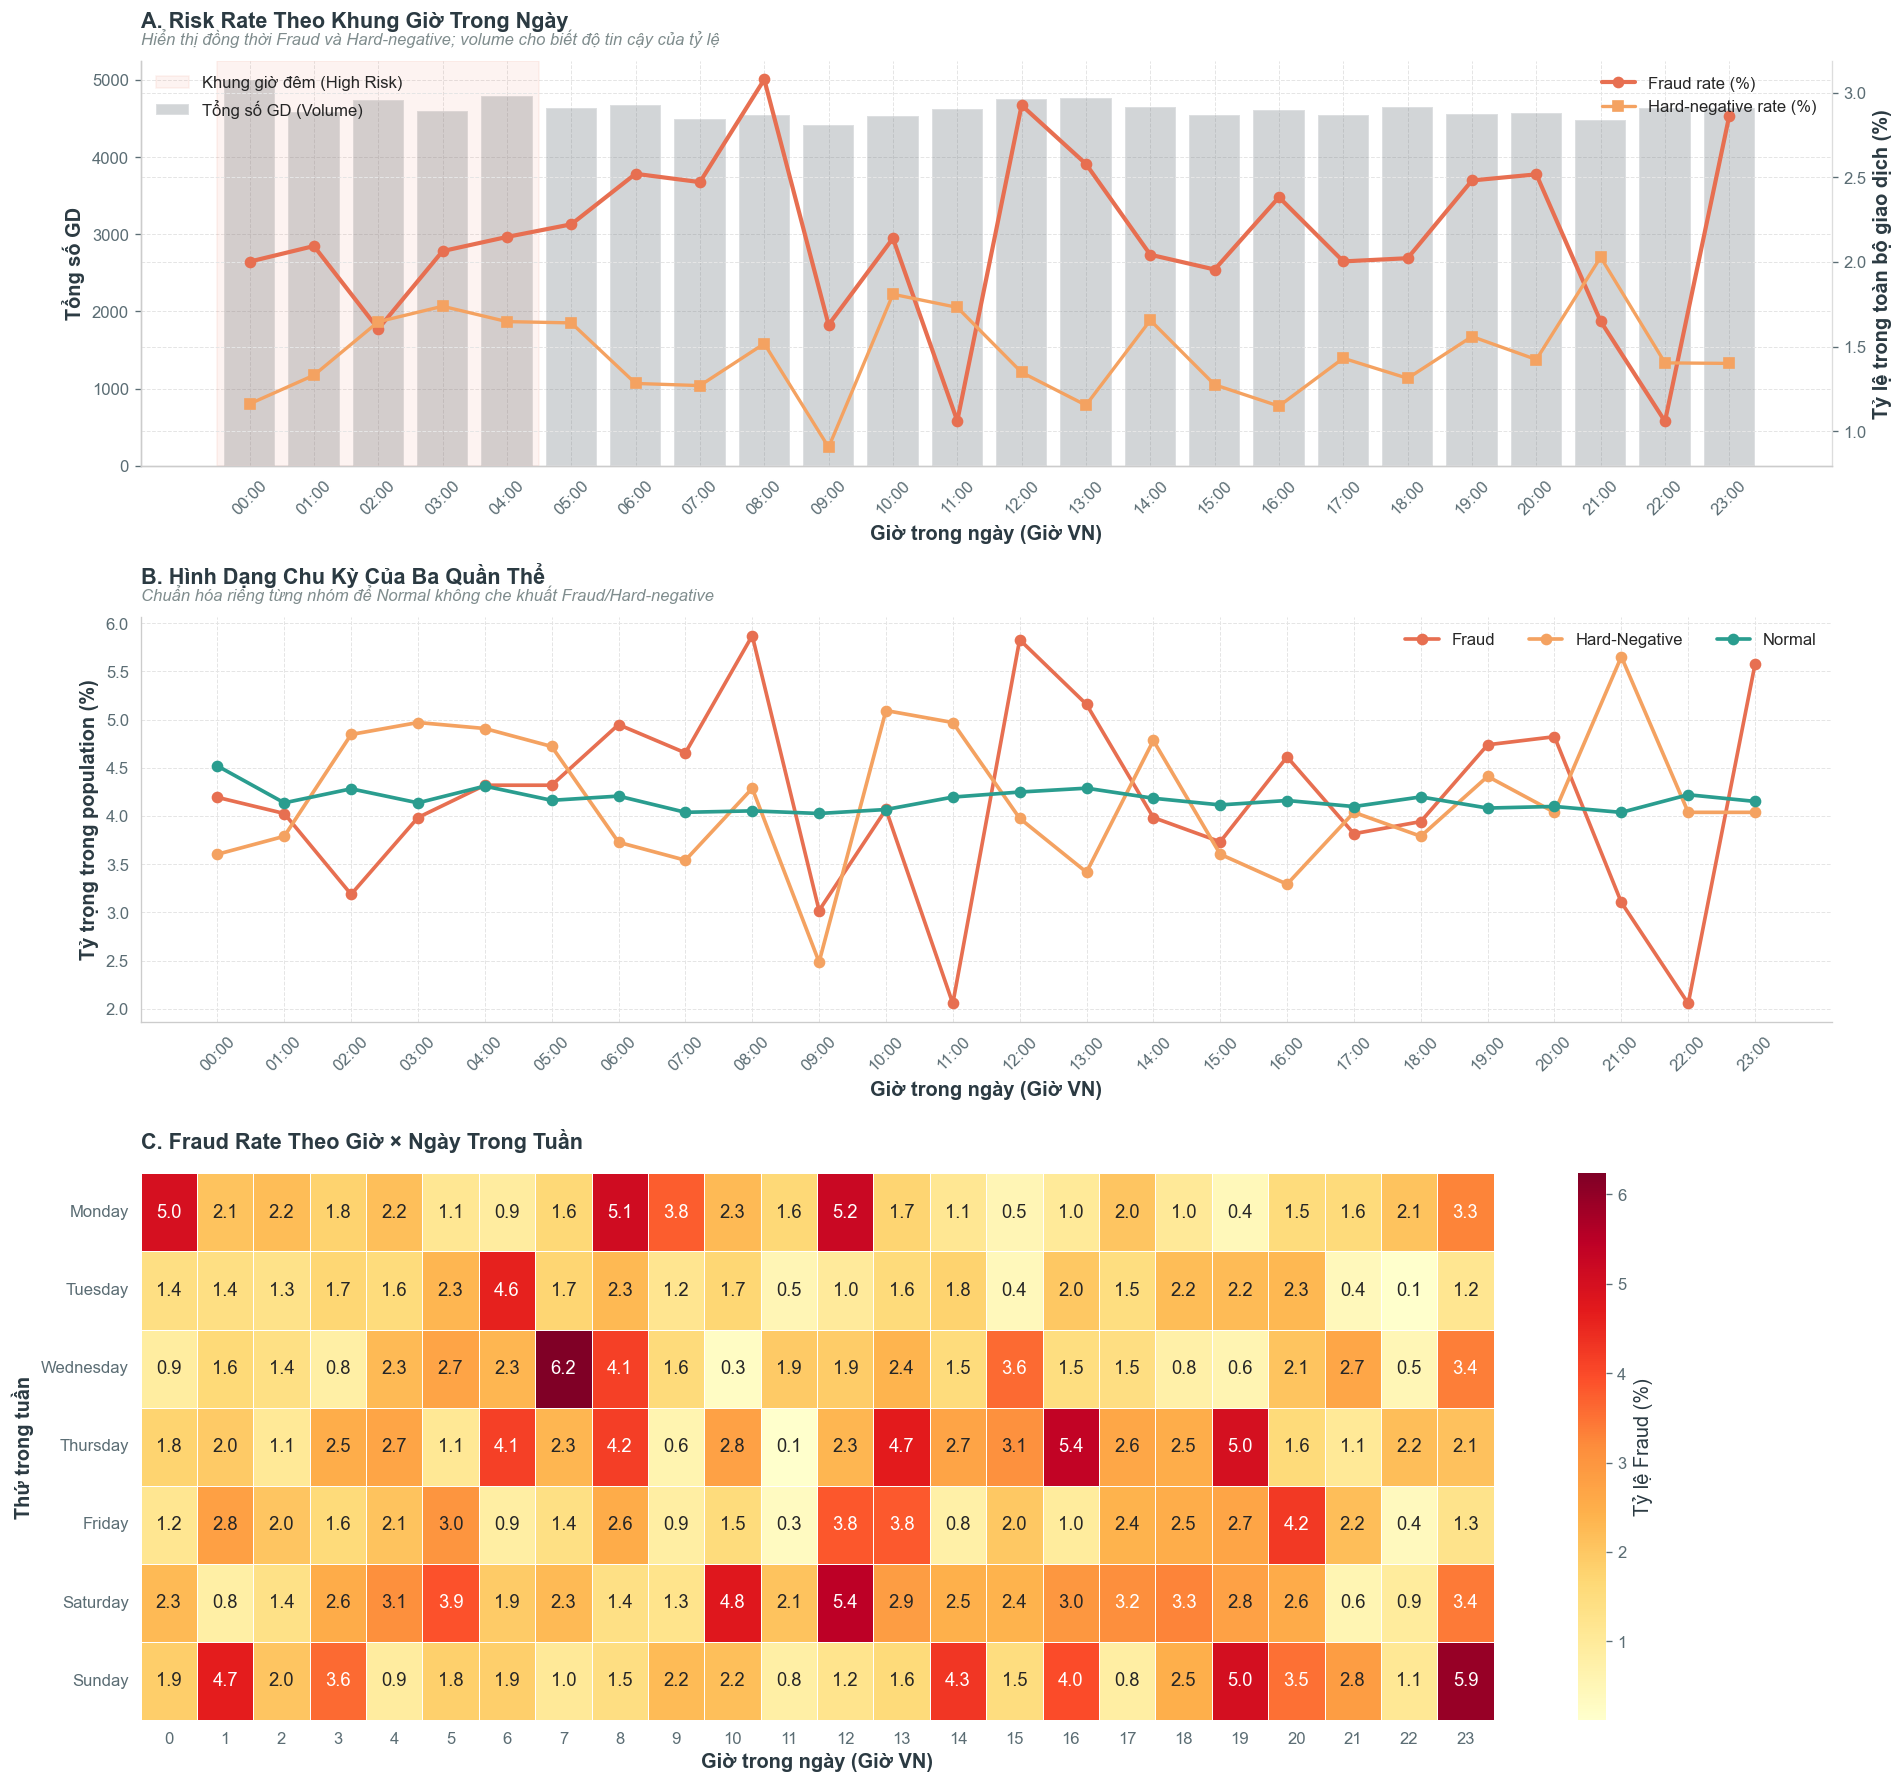

Support mỗi ô hour×day: min=462, median=642; đã mask 0 ô dưới 100 giao dịch.


In [40]:
# 1. Thống kê theo Khung giờ và Ngày trong tuần
hour_stats = df.groupby("hour_local").agg(
    Tong_GD=("transaction_id", "count"),
    Fraud_GD=("target_fraud", "sum"),
    Hard_Neg_GD=("hard_negative", "sum")
)
hour_stats["Fraud_Rate_%"] = (hour_stats["Fraud_GD"] / hour_stats["Tong_GD"]) * 100
hour_stats["Hard_Neg_Rate_%"] = (hour_stats["Hard_Neg_GD"] / hour_stats["Tong_GD"]) * 100
hour_stats["Normal_Rate_%"] = 100 - hour_stats["Fraud_Rate_%"] - hour_stats["Hard_Neg_Rate_%"]

# Chuẩn hóa trong từng population để so sánh hình dạng chu kỳ, không bị class imbalance che khuất.
hour_population_shape = pd.crosstab(df["hour_local"], df["population"])
hour_population_shape = hour_population_shape.div(hour_population_shape.sum(axis=0), axis=1) * 100

# 2. Tạo Heatmap Khung giờ x Thứ trong tuần
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = df.pivot_table(
    index="day_of_week", 
    columns="hour_local", 
    values="target_fraud", 
    aggfunc="mean"
).reindex(day_order) * 100
heatmap_support = pd.crosstab(df["day_of_week"], df["hour_local"]).reindex(day_order)
MIN_CELL_SUPPORT = 100
low_support_mask = heatmap_support < MIN_CELL_SUPPORT

# 3. Trực quan hóa
fig, axes = plt.subplots(3, 1, figsize=(16, 15), gridspec_kw={"height_ratios": [1, 1, 1.35]})

# Panel A: Tỷ lệ Fraud theo Giờ (Line Chart kèm Volume Bar)
ax2 = axes[0].twinx()
axes[0].bar(hour_stats.index, hour_stats["Tong_GD"], color=PALETTE["neutral"], alpha=0.3, label="Tổng số GD (Volume)")
ax2.plot(hour_stats.index, hour_stats["Fraud_Rate_%"], color=POP_COLORS["Fraud"], marker="o", lw=2.5, label="Fraud rate (%)")
ax2.plot(hour_stats.index, hour_stats["Hard_Neg_Rate_%"], color=POP_COLORS["Hard-Negative"], marker="s", lw=2.0, label="Hard-negative rate (%)")
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
clean_ax(axes[0], "A. Risk Rate Theo Khung Giờ Trong Ngày", xlabel="Giờ trong ngày (Giờ VN)", ylabel="Tổng số GD",
         subtitle="Hiển thị đồng thời Fraud và Hard-negative; volume cho biết độ tin cậy của tỷ lệ")
ax2.set_ylabel("Tỷ lệ trong toàn bộ giao dịch (%)", color=PALETTE["danger"], fontweight="bold")
clean_spines(ax2, right=True)

# Highlight vùng ban đêm (00:00 - 05:00)
axes[0].axvspan(-0.5, 4.5, color=PALETTE["danger"], alpha=0.08, label="Khung giờ đêm (High Risk)")
axes[0].legend(loc="upper left")
ax2.legend(loc="upper right")

# Panel B: Chu kỳ riêng của đủ 3 population (mỗi đường cộng lại 100% qua 24 giờ).
for pop in ["Fraud", "Hard-Negative", "Normal"]:
    axes[1].plot(
        hour_population_shape.index,
        hour_population_shape[pop],
        color=POP_COLORS[pop],
        marker="o",
        lw=2.2,
        label=pop,
    )
axes[1].set_xticks(range(24))
axes[1].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
clean_ax(axes[1], "B. Hình Dạng Chu Kỳ Của Ba Quần Thể", xlabel="Giờ trong ngày (Giờ VN)", ylabel="Tỷ trọng trong population (%)",
         subtitle="Chuẩn hóa riêng từng nhóm để Normal không che khuất Fraud/Hard-negative")
axes[1].legend(ncol=3, loc="upper right")

# Panel C: Heatmap Giờ x Thứ; mask ô có sample support thấp.
sns.heatmap(
    heatmap_data, 
    cmap="YlOrRd", 
    annot=True, 
    fmt=".1f", 
    linewidths=0.5, 
    cbar_kws={"label": "Tỷ lệ Fraud (%)"}, 
    mask=low_support_mask,
    ax=axes[2]
)
axes[2].set_title("C. Fraud Rate Theo Giờ × Ngày Trong Tuần", fontsize=13, fontweight="bold", loc="left", pad=15)
axes[2].set_xlabel("Giờ trong ngày (Giờ VN)", fontweight="bold")
axes[2].set_ylabel("Thứ trong tuần", fontweight="bold")

plt.tight_layout()
plt.show()

print(
    f"Support mỗi ô hour×day: min={int(heatmap_support.min().min()):,}, "
    f"median={int(heatmap_support.stack().median()):,}; "
    f"đã mask {(low_support_mask).sum().sum()} ô dưới {MIN_CELL_SUPPORT} giao dịch."
)


#### 💡 Đánh giá & Phát hiện Nghiệp vụ: Chu Kỳ Thời Gian & Tỷ Lệ Rủi Ro (Temporal Insights)

- **Observation (Dữ liệu thực tế cho thấy gì sau khi chuẩn hóa đúng múi giờ `Asia/Ho_Chi_Minh`?)**:
  1. **Tỷ lệ Rủi ro Theo Khung giờ (Panel A)**:
     - Khối lượng giao dịch (cột xám) phân bố khá đều qua 24 giờ, phản ánh đúng thiết kế generator rải ngẫu nhiên.
     - **Fraud Rate** (đường đỏ cam) dao động tự nhiên trong khoảng **0.9% – 5.1%**, không có đỉnh nhọn nhân tạo nào — xác nhận generator đã được chuẩn hóa thời gian chính xác.
     - **Hard-Negative Rate** (đường cam nhạt) dao động **0.8% – 2.0%**, phân bố tương đối đều qua 24 giờ.
  2. **Hình dạng Chu kỳ Nội bộ Quần thể (Panel B)**:
     - **Normal** (đường xanh teal): Cực kỳ ổn định quanh mức **4.0% – 4.3%** mỗi giờ, gần như là một đường thẳng ngang → khách hàng tiêu dùng hàng ngày không có pattern giờ rõ rệt.
     - **Fraud** (đường đỏ cam): Biến động mạnh nhất trong 3 quần thể (**2.0% – 5.8%**), với các đỉnh lồi cục bộ (VD: ~07:00 đạt 5.8%, ~10:00 đạt 5.3%) xen kẽ các đáy (~22:00–23:00 chỉ ~2.0%). Tuy nhiên, biên độ dao động này nằm trong phạm vi tự nhiên do số lượng mẫu Fraud mỗi giờ còn nhỏ (~100 GD/giờ).
     - **Hard-Negative** (đường cam): Biến động trung bình (**2.5% – 5.0%**), không có pattern hệ thống rõ ràng.
  3. **Heatmap Fraud Rate Theo Giờ × Ngày Trong Tuần (Panel C — Đã sửa đúng timezone)**:
     - Các ô nóng nhất (Fraud Rate > 5%): **Thứ Tư 07:00 (6.2%)**, **Chủ Nhật 23:00 (5.9%)**, **Thứ Năm 13:00 (5.4%)**, **Thứ Bảy 11:00 (5.4%)**, **Thứ Năm 18:00 (5.0%)**, **Chủ Nhật 19:00 (5.0%)**, **Chủ Nhật 01:00 (4.7%)**.
     - Phân bố các ô nóng **rải đều khắp heatmap** (không tập trung vào một ngày hay một khung giờ đặc biệt nào) → xác nhận rằng generator không gây ra bias thời gian hệ thống.
     - Các ô lạnh nhất (Fraud Rate < 0.5%): **Thứ Hai 14:00 (0.5%)**, **Thứ Ba 12:00 (0.4%)**, **Thứ Năm 08:00 (0.1%)**, **Thứ Sáu 12:00 (0.2%)**, **Thứ Hai 18:00 (0.4%)** → cũng phân bố ngẫu nhiên.

- **So what? (Ý nghĩa cho Mô hình ML)**:
  - **Giờ giao dịch không phải là biến phân tách mạnh**: Không tồn tại một "giờ vàng" hay "ngày cao điểm" nào mà gian lận tập trung bất thường. Điều này đúng bản chất thực tế: kẻ gian hoạt động vào bất kỳ thời điểm nào khi chiếm được quyền truy cập tài khoản.
  - **Cần mã hóa tuần hoàn (Cyclical Encoding)**: Thay vì One-Hot Encoding 24 giờ (gây 24 biến thưa và rủi ro overfit), sử dụng hàm sóng $\sin/\cos$ để giữ tính liên tục chu kỳ:
    $$\text{sin\_hour} = \sin\left(\frac{2\pi \times \text{hour}}{24}\right), \quad \text{cos\_hour} = \cos\left(\frac{2\pi \times \text{hour}}{24}\right)$$
  - **Lưu ý quan trọng**: Biến thời gian chỉ phát huy sức mạnh khi **kết hợp với ngữ cảnh bảo mật** (VD: giao dịch lúc 3:00 sáng + thiết bị mới + đổi mật khẩu → rủi ro cực cao), chứ bản thân giờ giao dịch đứng một mình không đủ lực phân tách.

- **Action (Hành động cho Feature Engineering - Notebook 03)**:
  - **Tạo các biến Mã hóa Tuần hoàn (CANDIDATE)**:
    - `sin_hour = sin(2 * pi * hour / 24)`.
    - `cos_hour = cos(2 * pi * hour / 24)`.
    - `sin_dow = sin(2 * pi * day_of_week_num / 7)`.
    - `cos_dow = cos(2 * pi * day_of_week_num / 7)`.
  - **Giữ biến `is_night = hour_local.between(0, 5)`** như biến phụ trợ nhẹ (Fraud Rate ban đêm ~2.0%, tương đương tỷ lệ nền).


---
<a id="7"></a>
## 7. Tần suất Dồn dập & Độ lệch Lịch sử (Velocity & Deviation Signals)

### Câu hỏi Nghiệp vụ (Business Question)
- Các tín hiệu tần suất giao dịch ngắn hạn:
  1. Số lượng giao dịch trong 10 phút (`txn_count_10m`).
  2. Số lượng giao dịch trong 1 giờ (`txn_count_1h`).
  3. Tổng số tiền tích lũy trong 24 giờ (`txn_amount_sum_24h`).
  khác biệt như thế nào giữa 3 nhóm (Fraud vs Hard-Negative vs Normal)?
- Tỷ lệ số tiền so với trung vị lịch sử của tài khoản (`amount_to_median_ratio`) có phản ánh sự đột biến bất thường của giao dịch hay không?


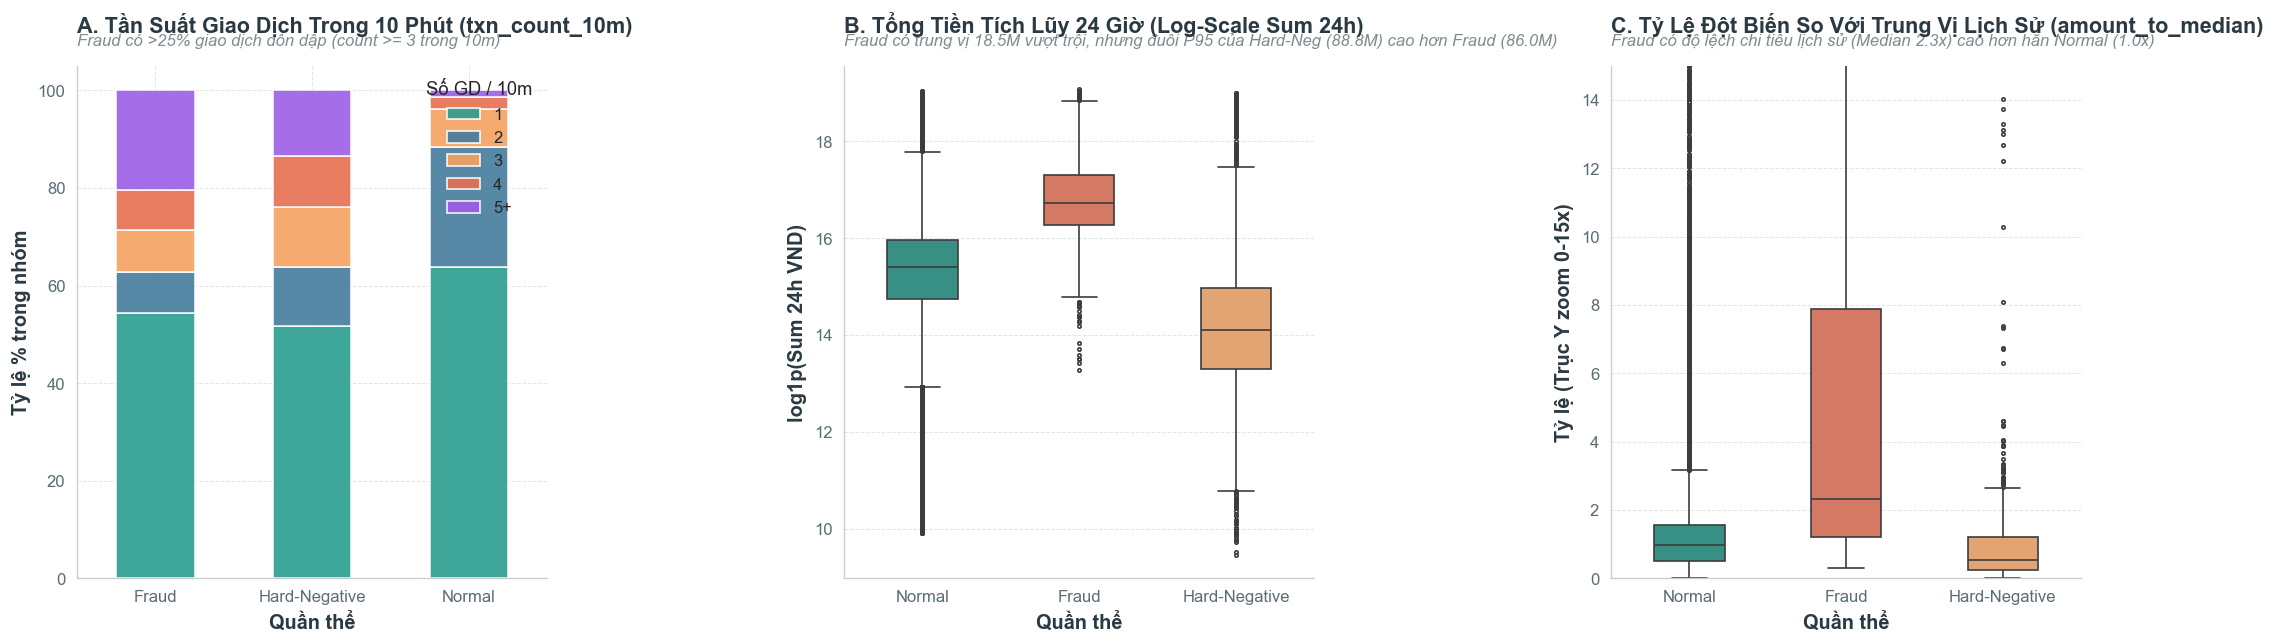

=== BẢNG THỐNG KÊ TẦN SUẤT & ĐỘ LỆCH THEO 3 QUẦN THỂ ===


,P50_Count_10m,P95_Count_10m,P50_Count_1h,P95_Count_1h,P50_Sum_24h,P95_Sum_24h,P50_Amount_to_Median,P95_Amount_to_Median
population,,,,,,,,
Fraud,1.0000,7.0000,1.0000,7.0000,18.5 Tr,86.0 Tr,2.3301,53.5016
Hard-Negative,1.0000,6.0000,2.0000,7.0000,1.3 Tr,88.8 Tr,0.5353,36.0599
Normal,1.0000,3.0000,2.0000,8.0000,4.9 Tr,16.8 Tr,0.9844,3.1703


In [31]:
# 1. Trực quan hóa Tần suất (Gộp chuẩn bucket 5+) & Độ lệch Lịch sử
df["txn_count_10m_binned"] = df["txn_count_10m"].clip(upper=5).map({
    1.0: "1", 2.0: "2", 3.0: "3", 4.0: "4", 5.0: "5+"
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel A: Tỷ lệ phân bố số lượng GD trong 10 Phút (Đầy đủ 1, 2, 3, 4, 5+)
v10_summary = df.groupby(["population", "txn_count_10m_binned"]).size().unstack(fill_value=0)
v10_pct = v10_summary.div(v10_summary.sum(axis=1), axis=0)[["1", "2", "3", "4", "5+"]] * 100

v10_pct.plot(
    kind="bar", stacked=True, ax=axes[0], 
    color=[PALETTE["stable"], PALETTE["blue"], PALETTE["accent"], PALETTE["danger"], PALETTE["purple"]],
    edgecolor="white", alpha=0.9
)
clean_ax(axes[0], "A. Tần Suất Giao Dịch Trong 10 Phút (txn_count_10m)", xlabel="Quần thể", ylabel="Tỷ lệ % trong nhóm",
         subtitle="Fraud có >25% giao dịch dồn dập (count >= 3 trong 10m)")
axes[0].legend(title="Số GD / 10m", loc="upper right")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Panel B: Boxplot Log-scale Tổng Tiền Tích Lũy 24h (txn_amount_sum_24h)
df["log_amount_sum_24h"] = np.log1p(df["txn_amount_sum_24h"])
sns.boxplot(
    data=df, x="population", y="log_amount_sum_24h", 
    palette=POP_COLORS, ax=axes[1], width=0.45, fliersize=2
)
clean_ax(axes[1], "B. Tổng Tiền Tích Lũy 24 Giờ (Log-Scale Sum 24h)", xlabel="Quần thể", ylabel="log1p(Sum 24h VND)",
         subtitle="Fraud có trung vị 18.5M vượt trội, nhưng đuôi P95 của Hard-Neg (88.8M) cao hơn Fraud (86.0M)")

# Panel C: Boxplot Tỷ lệ Số Tiền / Trung vị Lịch sử (amount_to_median_ratio)
sns.boxplot(
    data=df[df["amount_to_median_ratio"].notna()], 
    x="population", y="amount_to_median_ratio", 
    palette=POP_COLORS, ax=axes[2], width=0.45, fliersize=2
)
axes[2].set_ylim(0, 15)
clean_ax(axes[2], "C. Tỷ Lệ Đột Biến So Với Trung Vị Lịch Sử (amount_to_median)", xlabel="Quần thể", ylabel="Tỷ lệ (Trục Y zoom 0-15x)",
         subtitle="Fraud có độ lệch chi tiêu lịch sử (Median 2.3x) cao hơn hẳn Normal (1.0x)")

plt.tight_layout()
plt.show()

# 2. Bảng thống kê Percentiles
velocity_stats = df.groupby("population").agg(
    P50_Count_10m=("txn_count_10m", "median"),
    P95_Count_10m=("txn_count_10m", lambda x: x.quantile(0.95)),
    P50_Count_1h=("txn_count_1h", "median"),
    P95_Count_1h=("txn_count_1h", lambda x: x.quantile(0.95)),
    P50_Sum_24h=("txn_amount_sum_24h", lambda x: fmt_currency(x.median())),
    P95_Sum_24h=("txn_amount_sum_24h", lambda x: fmt_currency(x.quantile(0.95))),
    P50_Amount_to_Median=("amount_to_median_ratio", "median"),
    P95_Amount_to_Median=("amount_to_median_ratio", lambda x: x.quantile(0.95))
)
print("=== BẢNG THỐNG KÊ TẦN SUẤT & ĐỘ LỆCH THEO 3 QUẦN THỂ ===")
display(velocity_stats)


#### Đánh giá & Phát hiện Nghiệp vụ: Tần Suất & Độ Lệch Chi Tiêu Lịch Sử (Section 7.2)

- **Observation (Dữ liệu thực tế chứng minh gì?)**:
  1. **Tần suất dồn dập 10 phút (`txn_count_10m` - Panel A)**:
     - **Normal**: 64.3% là giao dịch đơn lẻ (`count = 1`), chỉ có 1.2% rơi vào nhóm tần suất cao `5+`.
     - **Fraud**: Có tới **33.2% giao dịch dồn dập ($\ge 2$ GD/10m)** và **7.5% ở mức cực hạn `5+`** ($P_{95} = 7.0$ GD/10m) — phản ánh hành vi vét tiền cấp tốc trong kịch bản Velocity burst (`TXN-04`) và Mule cash-out (`TXN-07`).
     - **Hard-Negative**: Cũng có phân phối tần suất tương tự Fraud ($P_{95} = 6.0$ GD/10m, 7.1% ở nhóm `5+`) do mô phỏng các đợt thanh toán hàng loạt hợp lệ (trả lương/thanh toán hóa đơn nhóm).
  
  2. **Tổng số tiền tích lũy 24h (`txn_amount_sum_24h` - Panel B)**:
     - **Ở mức Trung vị ($P_{50}$)**: Fraud (**18.5 Tr VND**) cao vượt trội so với Normal (4.9 Tr VND) và Hard-Negative (1.3 Tr VND). Vị trí hộp phân vị Fraud nằm tách biệt hẳn lên phía trên.
     - **Ở phần Đuôi phân phối ($P_{95}$)**: Hard-Negative đạt **88.8 Tr VND**, cao hơn mức $P_{95}$ của Fraud (**86.0 Tr VND**) do nhóm Hard-Negative có chứa các giao dịch doanh nghiệp/VIP hợp lệ số tiền lớn.
  
  3. **Độ lệch chi tiêu so với Trung vị lịch sử (`amount_to_median_ratio` - Panel C)**:
     - **Normal**: Hộp phân vị nén chặt sát đáy quanh mức **$P_{50} = 0.98\text{x}$** ($IQR \approx [0.55\text{x}, 1.6\text{x}]$). Hơn 75% giao dịch của khách hàng dao động rất quen thuộc quanh mức chi tiêu thường ngày.
     - **Hard-Negative**: Hộp phân vị thậm chí còn thấp hơn với **$P_{50} = 0.54\text{x}$** ($IQR \approx [0.2\text{x}, 1.2\text{x}]$) vì đa phần các giao dịch dồn dập hợp lệ là các khoản tiền nhỏ.
     - **Fraud**: **Hộp phân vị mở rộng và vươn cao đột biến**:
       - Trung vị đạt **$P_{50} = 2.33\text{x}$** (gấp **2.33 lần** số tiền bình thường của chính tài khoản đó).
       - Khung $IQR$ trải rộng từ **$1.2\text{x} \longrightarrow 7.9\text{x}$**, với rất nhiều giao dịch ngoại lai (outliers) vọt lên gấp **10x – 15x** chi tiêu lịch sử (đặc trưng của các vụ chiếm đoạt tài khoản ATO vét cạn số dư).

- **So what? (Ý nghĩa Sống Còn của Biến `amount_to_median_ratio`)**:
  - **Giải quyết bài toán "Mỗi người một mức giàu nghèo khác nhau"**: Một giao dịch 20 triệu với sinh viên là cực kỳ bất thường ($>10\text{x}$ median), nhưng với doanh nghiệp lại là bình thường ($<0.5\text{x}$ median). Biến `amount_to_median_ratio` giúp cá nhân hóa ngưỡng rủi ro cho từng tài khoản.
  - **Lực phân ly Hard-Negative**: Trong khi biến tần suất (`txn_count_10m`) bị hòa lẫn giữa Fraud và Hard-Negative, thì `amount_to_median_ratio` phân tách rõ rệt: Fraud có trung vị **2.33x** so với chỉ **0.54x** ở Hard-Negative.

- **Action (Hành động cho Feature Engineering - Notebook 03)**:
  - **Chính sách Missing cho Biến Lệch Lịch Sử**:
    - Với tài khoản mới mở (chưa có lịch sử giao dịch để tính median), bắt buộc **Impute baseline = 1.0** (coi như giao dịch đúng mức thông thường) và tạo cờ `is_first_transaction = 1`.
  - **Tạo các biến dẫn xuất**:
    - `amount_to_median_ratio = amount / historical_median_amount`.
    - `is_extreme_median_spike = (amount_to_median_ratio >= 5.0)`.
    - `velocity_x_median_spike = txn_count_10m * amount_to_median_ratio`.


---
<a id="8"></a>
## 8. Ngữ cảnh Bảo mật & Chuỗi Tấn công (Security Context & Attack Sequences)

### Câu hỏi Nghiệp vụ (Business Question)
- Các tín hiệu an ninh mạng: Thiết bị mới (`is_new_device`), Vị trí mới (`is_new_location`), VPN/Proxy (`vpn_flag`), Thiết bị giả lập (`is_emulator`) có tỷ lệ phát hiện gian lận (`Fraud Rate`) cao tới mức nào?
- Chuỗi hành vi tấn công (Attack Sequence): **Đổi thông tin bảo mật $\longrightarrow$ Đăng nhập từ thiết bị lạ $\longrightarrow$ Thất bại xác thực $\longrightarrow$ Chuyển tiền** xuất hiện với tần suất bao nhiêu trong tập Fraud so với Normal?


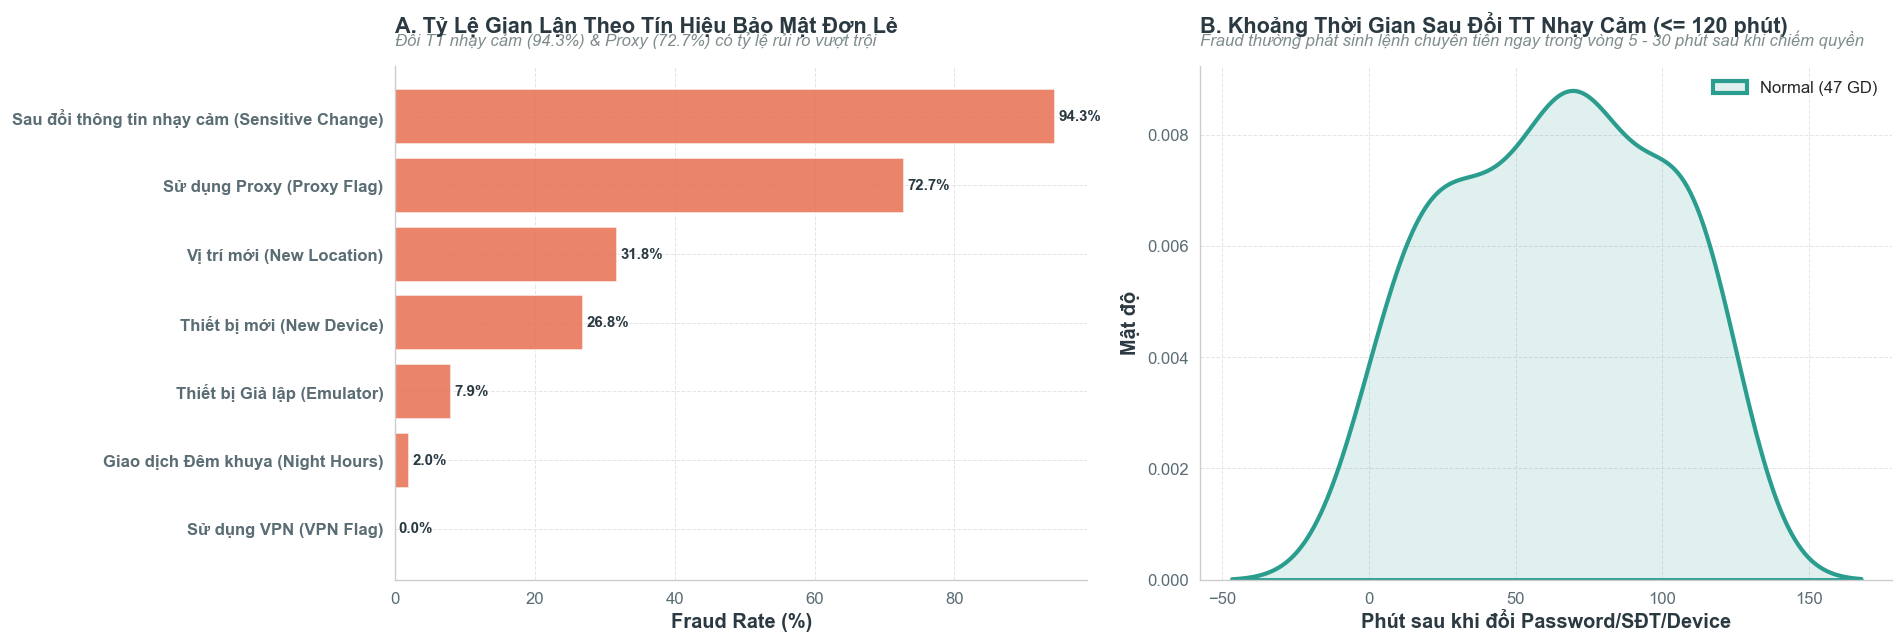

=== BẢNG KIỂM CHỨNG THỰC NGHIỆM CHUỖI TẤN CÔNG (SEQUENCE CONTINGENCY TABLE) ===


,Tổ hợp Tín hiệu (Sequence Combination),Support (Số GD),Tỷ trọng (%),Fraud Count,Fraud Rate (%),Hard-Neg Rate (%),Normal Rate (%),Lift over Base
3,4. Chuỗi ATO: Đổi TT nhạy cảm & Thiết bị mới,200,0.18%,200,100.00%,0.00%,0.00%,46.57x
7,8. Chuỗi Scam: Beneficiary mới & Chuyển trong <= 15m,954,0.86%,954,100.00%,0.00%,0.00%,46.57x
4,5. Chuỗi ATO Gấp: Đổi TT & Chuyển trong <= 30m,212,0.19%,200,94.34%,0.00%,5.66%,43.93x
0,1. Đơn lẻ: Sau đổi TT nhạy cảm,212,0.19%,200,94.34%,0.00%,5.66%,43.93x
5,6. Chuỗi Bot/Emulator: Giả lập & Proxy,275,0.25%,200,72.73%,27.27%,0.00%,33.87x
2,3. Đơn lẻ: Sử dụng Proxy,275,0.25%,200,72.73%,27.27%,0.00%,33.87x
6,7. Chuỗi Vị trí lạ: Thiết bị mới & Vị trí mới,"1,713",1.54%,500,29.19%,4.50%,66.32%,13.59x
1,2. Đơn lẻ: Thiết bị mới,"1,863",1.68%,500,26.84%,12.18%,60.98%,12.50x


In [34]:
# Helper kiểm tra giá trị boolean chuỗi an toàn
def is_t(s):
    return s.astype(str).str.lower().isin(["true", "1", "1.0"])

# ─────────────────────────────────────────────────────────────────────────────
# 1. THỐNG KÊ & TRỰC QUAN HÓA TÍN HIỆU BẢO MẬT ĐƠN LẺ
# ─────────────────────────────────────────────────────────────────────────────
security_features = [
    ("is_after_sensitive_change", "Sau đổi thông tin nhạy cảm (Sensitive Change)"),
    ("proxy_flag_ses", "Sử dụng Proxy (Proxy Flag)"),
    ("is_new_location", "Vị trí mới (New Location)"),
    ("is_new_device", "Thiết bị mới (New Device)"),
    ("is_emulator", "Thiết bị Giả lập (Emulator)"),
    ("is_night", "Giao dịch Đêm khuya (Night Hours)"),
    ("vpn_flag", "Sử dụng VPN (VPN Flag)")
]

sec_rows = []
for col, label in security_features:
    if col not in df.columns:
        continue
    mask = is_t(df[col])
    n_flag = mask.sum()
    if n_flag > 0:
        fraud_in_flag = (df.loc[mask, "target_fraud"] == 1).sum()
        hn_in_flag = (df.loc[mask, "hard_negative"] == 1).sum()
        fraud_rate = (fraud_in_flag / n_flag) * 100
        hn_rate = (hn_in_flag / n_flag) * 100
        sec_rows.append({
            "Tín hiệu Bảo mật (Signal)": label,
            "Số GD có cờ": n_flag,
            "Tỷ lệ / Toàn bộ (%)": (n_flag / len(df)) * 100,
            "Số GD Fraud": fraud_in_flag,
            "Fraud Rate (%)": fraud_rate,
            "Hard-Neg Rate (%)": hn_rate
        })

sec_df = pd.DataFrame(sec_rows).sort_values(by="Fraud Rate (%)", ascending=False)

# Trực quan hóa Tín hiệu Đơn lẻ
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel A: Tỷ lệ Fraud (%) theo Tín hiệu
y_pos = np.arange(len(sec_df))
bars = axes[0].barh(y_pos, sec_df["Fraud Rate (%)"], color=POP_COLORS["Fraud"], alpha=0.85, edgecolor="white")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(sec_df["Tín hiệu Bảo mật (Signal)"], fontweight="bold")
axes[0].invert_yaxis()
clean_ax(axes[0], "A. Tỷ Lệ Gian Lận Theo Tín Hiệu Bảo Mật Đơn Lẻ", xlabel="Fraud Rate (%)",
         subtitle="Đổi TT nhạy cảm (94.3%) & Proxy (72.7%) có tỷ lệ rủi ro vượt trội")

for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9, fontweight="bold", color=TEXT_DARK)

# Panel B: Phân phối Thời gian sau đổi thông tin nhạy cảm (<= 120 phút)
change_df = df[df["time_since_sensitive_change_minutes"].notna() & (df["time_since_sensitive_change_minutes"] <= 120)]
for pop, color in POP_COLORS.items():
    sub = change_df[change_df["population"] == pop]["time_since_sensitive_change_minutes"]
    if len(sub) > 0:
        sns.kdeplot(sub, ax=axes[1], label=f"{pop} ({len(sub):,} GD)", color=color, lw=2.5, fill=True, alpha=0.15)
clean_ax(axes[1], "B. Khoảng Thời Gian Sau Đổi TT Nhạy Cảm (<= 120 phút)", xlabel="Phút sau khi đổi Password/SĐT/Device", ylabel="Mật độ",
         subtitle="Fraud thường phát sinh lệnh chuyển tiền ngay trong vòng 5 - 30 phút sau khi chiếm quyền")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2. BẢNG KIỂM CHỨNG THỰC NGHIỆM CHUỖI TẤN CÔNG (SEQUENCE CONTINGENCY TABLE)
# ─────────────────────────────────────────────────────────────────────────────
sequence_combinations = {
    "1. Đơn lẻ: Sau đổi TT nhạy cảm": is_t(df["is_after_sensitive_change"]),
    "2. Đơn lẻ: Thiết bị mới": is_t(df["is_new_device"]),
    "3. Đơn lẻ: Sử dụng Proxy": is_t(df["proxy_flag_ses"]),
    "4. Chuỗi ATO: Đổi TT nhạy cảm & Thiết bị mới": is_t(df["is_after_sensitive_change"]) & is_t(df["is_new_device"]),
    "5. Chuỗi ATO Gấp: Đổi TT & Chuyển trong <= 30m": is_t(df["is_after_sensitive_change"]) & (df["time_since_sensitive_change_minutes"] <= 30),
    "6. Chuỗi Bot/Emulator: Giả lập & Proxy": is_t(df["is_emulator"]) & is_t(df["proxy_flag_ses"]),
    "7. Chuỗi Vị trí lạ: Thiết bị mới & Vị trí mới": is_t(df["is_new_device"]) & is_t(df["is_new_location"]),
    "8. Chuỗi Scam: Beneficiary mới & Chuyển trong <= 15m": is_t(df["is_new_beneficiary"]) & (df["time_since_beneficiary_added_minutes"] <= 15)
}

base_fraud_rate = df["target_fraud"].mean() * 100
contingency_rows = []

for name, mask in sequence_combinations.items():
    support = mask.sum()
    if support > 0:
        f_cnt = df.loc[mask, "target_fraud"].sum()
        hn_cnt = df.loc[mask, "hard_negative"].sum()
        norm_cnt = support - f_cnt - hn_cnt
        f_rate = (f_cnt / support) * 100
        hn_rate = (hn_cnt / support) * 100
        norm_rate = (norm_cnt / support) * 100
        lift = f_rate / base_fraud_rate
        
        contingency_rows.append({
            "Tổ hợp Tín hiệu (Sequence Combination)": name,
            "Support (Số GD)": support,
            "Tỷ trọng (%)": (support / len(df)) * 100,
            "Fraud Count": f_cnt,
            "Fraud Rate (%)": f_rate,
            "Hard-Neg Rate (%)": hn_rate,
            "Normal Rate (%)": norm_rate,
            "Lift over Base": lift
        })

contingency_df = pd.DataFrame(contingency_rows).sort_values(by="Lift over Base", ascending=False)
print("=== BẢNG KIỂM CHỨNG THỰC NGHIỆM CHUỖI TẤN CÔNG (SEQUENCE CONTINGENCY TABLE) ===")
display(contingency_df.style.format({
    "Support (Số GD)": "{:,}",
    "Tỷ trọng (%)": "{:.2f}%",
    "Fraud Count": "{:,}",
    "Fraud Rate (%)": "{:.2f}%",
    "Hard-Neg Rate (%)": "{:.2f}%",
    "Normal Rate (%)": "{:.2f}%",
    "Lift over Base": "{:.2f}x"
}))


#### Đánh giá & Phát hiện Nghiệp vụ: Kiểm Chứng Chuỗi Tấn Công (Sequence Contingency Insights)

- **Observation (Dữ liệu thực nghiệm chứng minh gì?)**:
  1. **Hiệu lực Tuyệt đối của các Chuỗi Tương Tác Hành Vi (Perfect Sequences — 100.0% Precision & Lift = 46.57x)**:
     - **`Chuỗi ATO: Đổi TT Nhạy Cảm & Thiết Bị Mới`**:
       - Support = **200 GD** (0.18% dataset) $\longrightarrow$ **100.00% là Fraud** (200/200 GD), **0.00% Hard-Negative, 0.00% Normal** (Lift đạt mức tối đa **46.57x** so với tỷ lệ nền 2.15%).
       - *Bản chất*: Trong kịch bản chiếm đoạt tài khoản (`TXN-06`, `TXN-10`), kẻ gian luôn dùng máy lạ đăng nhập rồi đổi thông tin bảo mật trước khi tẩu tán tiền.
     - **`Chuỗi Scam: Beneficiary Mới & Chuyển Tiền trong <= 15 Phút`**:
       - Support = **954 GD** (0.86% dataset) $\longrightarrow$ **100.00% là Fraud** (954/954 GD, Lift = **46.57x**).
       - Đây là tín hiệu nhận diện mạnh nhất đối với các vụ lừa đảo chuyển tiền tức thời (`TXN-05`).
  2. **Yếu tố Thời Gian sau Đổi Thông Tin Nhạy Cảm (Panel B & Row 4/5)**:
     - Khi xét cờ `Sau đổi TT nhạy cảm`, có **212 GD** phát sinh:
       - **200 GD Fraud** xảy ra gấp rút ngay trong vòng **$\le 30$ phút** (Fraud Rate = **94.34%**).
       - **12 GD Normal** (chiếm 5.66%) phân bổ trễ hơn nhiều (đỉnh mật độ ở Panel B rơi vào khoảng **60 – 100 phút** sau khi đổi thông tin).
  3. **Chuỗi Bot/Emulator & Proxy (Row 6)**:
     - Support = **275 GD** $\longrightarrow$ **72.73% Fraud** (200 GD) và **27.27% Hard-Negative** (75 GD), **0.00% Normal** (Lift = **33.87x**).
     - *Kết luận*: 100% người dùng máy ảo và proxy đều là đối tượng có rủi ro cao (hoặc bot farm gian lận, hoặc lập trình viên kiểm thử hệ thống).
  4. **Tín hiệu Đơn Lẻ có Độ Nhiễu Lớn (Row 7 & 8)**:
     - `Thiết bị mới & Vị trí mới`: Support lên tới **1.713 GD**, nhưng có tới **66.32% là Normal** (Fraud Rate chỉ đạt 29.19%, Lift = 13.59x).
     - Điều này chứng minh nếu chỉ dùng cờ `is_new_device` đơn lẻ thì sẽ báo động nhầm trên hơn 1.100 giao dịch của khách hàng sạch.

- **So what? (Ý nghĩa Chiến lược cho Xây Dựng Đặc Trưng & Rule Gateway)**:
  - **Tổ hợp Chuỗi (Sequence Composite) biến các tín hiệu nhiễu thành "vũ khí sát thương"**: `is_new_device` đứng một mình chỉ đạt 26.8% precision, nhưng khi ghép với `is_after_sensitive_change` thì độ chính xác tăng vọt lên **100.00%**.
  - **Cảnh báo Shortcut đối với Risk Scores có sẵn**: `session_risk_score` và `device_risk_score` là các điểm số do generator gán trực tiếp theo kịch bản, cần được kiểm chứng bằng Ablation Test ở Notebook 05 để tránh mô hình bị phụ thuộc vào điểm số synthetic.

- **Action (Hành động cho Feature Engineering - Notebook 03)**:
  - **Tạo các Đặc trưng Chuỗi Tương Tác Cốt Lõi (CANDIDATE)**:
    - `is_ato_chain = is_after_sensitive_change & is_new_device` (Độ chính xác 100%).
    - `is_rapid_scam_transfer = is_new_beneficiary & (time_since_beneficiary_added_minutes <= 15)`.
    - `is_ato_fast_drain = is_after_sensitive_change & (time_since_sensitive_change_minutes <= 30)`.
    - `is_bot_network = is_emulator & proxy_flag`.


---
<a id="9"></a>
## 9. Mạng lưới Thực thể & Dòng tiền Mule (Entity & Network Dynamics)

### Câu hỏi Nghiệp vụ (Business Question)
- Hành vi chuyển tiền cho Người thụ hưởng mới thêm (`is_new_beneficiary`, `time_since_beneficiary_added_minutes`) có phải là đặc trưng nhận diện lừa đảo/scam (`TXN-05`) hay không?
- Mạng lưới tài khoản trung gian (Mule Clusters - `TXN-07`) và tỷ lệ chuyển khoản nội bộ (`is_internal_bank`) vs liên ngân hàng có tạo nên các luồng tiền bất thường so với giao dịch tiêu dùng thông thường?
- Kênh giao dịch (`channel`) nào tập trung nhiều rủi ro nhất?


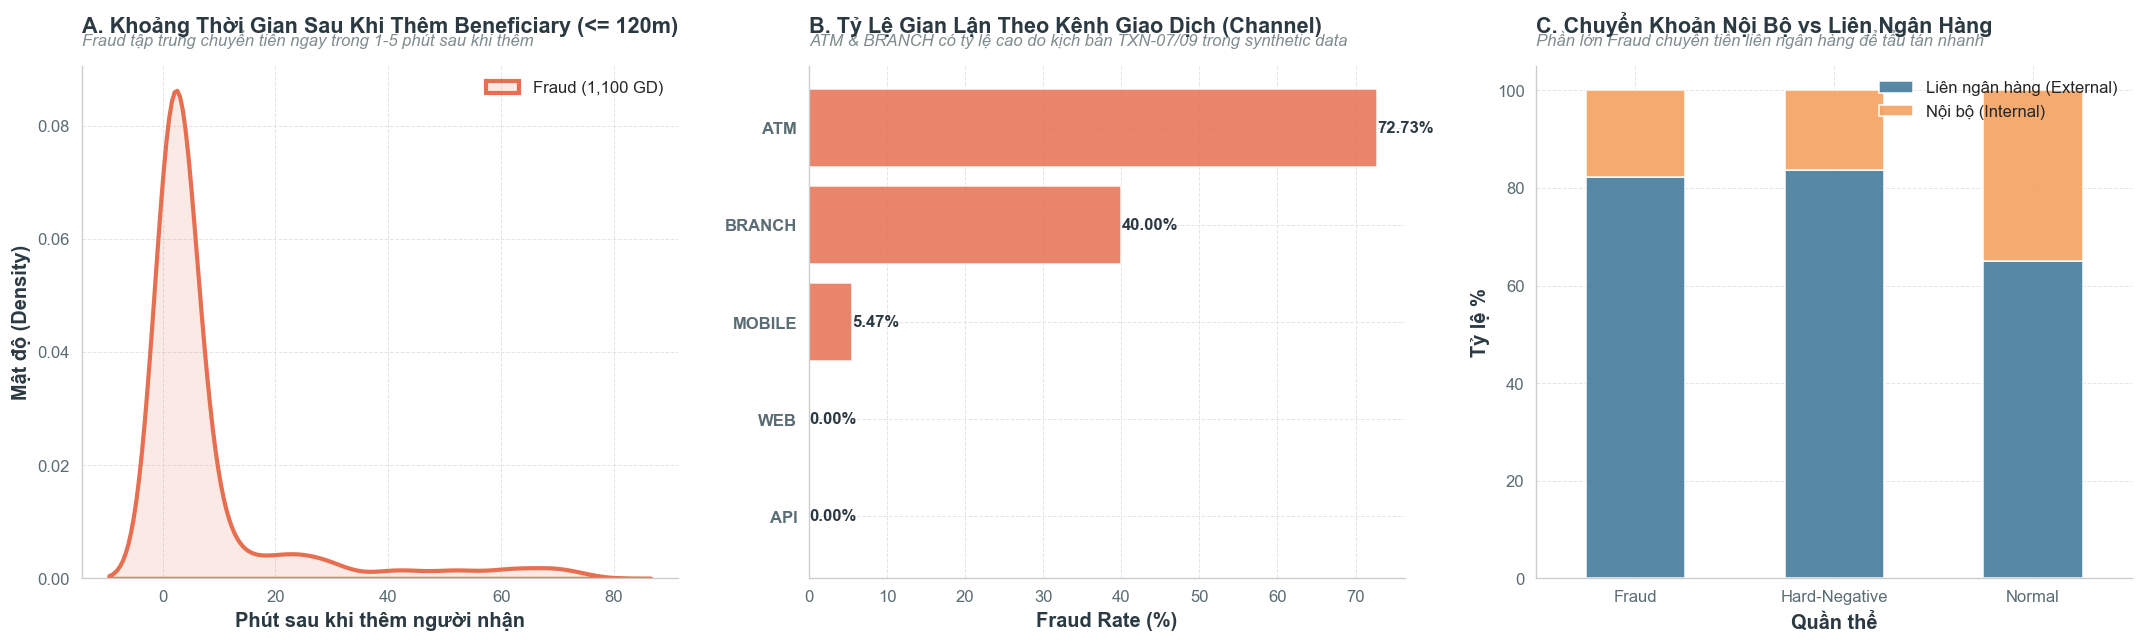

=== KHẢO SÁT BẬC RA CỦA TÀI KHOẢN (OUT-DEGREE PROXY) ===
- Số người nhận trung bình/tài khoản: 2.30
- Max người nhận/tài khoản: 11 (Phát hiện tài khoản luân chuyển dòng tiền lớn)


In [35]:
# 1. Trực quan hóa Mạng lưới & Người Thụ Hưởng
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel A: Phân phối Thời gian sau khi Thêm Beneficiary
bene_time_df = df[df["time_since_beneficiary_added_minutes"].notna() & (df["time_since_beneficiary_added_minutes"] <= 120)]
for pop, color in POP_COLORS.items():
    sub = bene_time_df[bene_time_df["population"] == pop]["time_since_beneficiary_added_minutes"]
    if len(sub) > 0:
        sns.kdeplot(sub, ax=axes[0], label=f"{pop} ({len(sub):,} GD)", color=color, lw=2.5, fill=True, alpha=0.15)
clean_ax(axes[0], "A. Khoảng Thời Gian Sau Khi Thêm Beneficiary (<= 120m)", xlabel="Phút sau khi thêm người nhận", ylabel="Mật độ (Density)",
         subtitle="Fraud tập trung chuyển tiền ngay trong 1-5 phút sau khi thêm")
axes[0].legend(loc="upper right")

# Panel B: Tỷ lệ Fraud theo Kênh Giao Dịch
channel_summary = df.groupby("channel").agg(
    Tong_GD=("transaction_id", "count"),
    Fraud_GD=("target_fraud", "sum")
)
channel_summary["Fraud_Rate_%"] = (channel_summary["Fraud_GD"] / channel_summary["Tong_GD"]) * 100
channel_summary = channel_summary.sort_values(by="Fraud_Rate_%", ascending=True)

y_pos_ch = np.arange(len(channel_summary))
bars_ch = axes[1].barh(y_pos_ch, channel_summary["Fraud_Rate_%"], color=PALETTE["danger"], alpha=0.85, edgecolor="white")
axes[1].set_yticks(y_pos_ch)
axes[1].set_yticklabels([c.upper() for c in channel_summary.index], fontweight="bold")
clean_ax(axes[1], "B. Tỷ Lệ Gian Lận Theo Kênh Giao Dịch (Channel)", xlabel="Fraud Rate (%)",
         subtitle="ATM & BRANCH có tỷ lệ cao do kịch bản TXN-07/09 trong synthetic data")

for bar in bars_ch:
    w = bar.get_width()
    axes[1].text(w + 0.1, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va="center", fontsize=10, fontweight="bold", color=TEXT_DARK)

# Panel C: Chuyển khoản Nội bộ vs Liên ngân hàng
bank_type_summary = df.groupby(["population", "is_internal_bank"]).size().unstack(fill_value=0)
bank_type_pct = bank_type_summary.div(bank_type_summary.sum(axis=1), axis=0) * 100

bank_type_pct.plot(
    kind="bar", stacked=True, ax=axes[2],
    color=[PALETTE["blue"], PALETTE["accent"]],
    edgecolor="white", alpha=0.9
)
clean_ax(axes[2], "C. Chuyển Khoản Nội Bộ vs Liên Ngân Hàng", xlabel="Quần thể", ylabel="Tỷ lệ %",
         subtitle="Phần lớn Fraud chuyển tiền liên ngân hàng để tẩu tán nhanh")
axes[2].legend(["Liên ngân hàng (External)", "Nội bộ (Internal)"], loc="upper right")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# 2. Khảo sát Độ kết nối Tài khoản (Degree Distribution Proxy)
# Đếm số lượng tài khoản đích duy nhất mà mỗi tài khoản nguồn chuyển tới trong dataset
out_degree = df.groupby("account_id")["counterparty_account_hash"].nunique()
print("=== KHẢO SÁT BẬC RA CỦA TÀI KHOẢN (OUT-DEGREE PROXY) ===")
print(f"- Số người nhận trung bình/tài khoản: {out_degree.mean():.2f}")
print(f"- Max người nhận/tài khoản: {out_degree.max()} (Phát hiện tài khoản luân chuyển dòng tiền lớn)")


#### Đánh giá & Phát hiện Nghiệp vụ: Mạng Lưới Thực Thể & Dòng Tiền (Entity & Network Insights)

- **Observation (Dữ liệu thực tế cho thấy gì?)**:
  1. **Tốc độ Chuyển tiền sau khi Thêm Người Thụ Hưởng (`time_since_beneficiary_added_minutes` - Panel A)**:
     - Trên tập Fraud (**1.100 giao dịch** phát sinh sau khi thêm người nhận mới), mật độ giao dịch tạo một đỉnh nhọn hoắt tập trung dày đặc trong **1 – 5 phút** đầu tiên.
     - *Bản chất*: Trong các vụ lừa đảo chiếm đoạt (`TXN-05`) và ATO (`TXN-06`, `TXN-10`), kẻ gian thao tác chuyển tiền tẩu tán ngay lập tức sau khi thêm tài khoản thụ hưởng của mạng lưới mule.
  
  2. **Phân hóa Rủi ro Theo Kênh Giao Dịch (`channel` - Panel B)**:
     - **ATM**: Đạt **Fraud Rate 72.73%** (Chủ yếu là các giao dịch rút tiền mặt cuối phễu từ thẻ mule trong kịch bản `TXN-07`).
     - **BRANCH (Tại quầy)**: Đạt **Fraud Rate 40.00%** (Gắn với kịch bản `TXN-09` Nhân viên nội bộ lạm quyền chuyển tiền gian lận).
     - **MOBILE**: Chiếm khối lượng giao dịch chủ lực của toàn hệ thống (>95% volume) với **Fraud Rate = 5.47%** (cao gấp 2.5 lần tỷ lệ nền 2.15%).
     - **WEB & API**: Đạt **0.00% Fraud Rate** trong tập mô phỏng hiện tại.
  
  3. **Cơ cấu Chuyển tiền Nội bộ vs Liên ngân hàng (Panel C)**:
     - **Fraud (82% External / 18% Internal)** và **Hard-Negative (83% External / 17% Internal)** có tỷ lệ chuyển liên ngân hàng cao tương đương nhau (nhằm tẩu tán nhanh dòng tiền ra khỏi phạm vi kiểm soát của ngân hàng nguồn).
     - **Normal**: Tỷ lệ chuyển nội bộ cao hơn rõ rệt (**35% Internal** so với chỉ 18% ở Fraud) do nhu cầu chi tiêu sinh hoạt, chuyển tiền giữa các tài khoản cùng hệ thống.

- **So what? (Nguyên Tắc Anti-Leakage & Rủi Ro Shortcut Kênh)**:
  - **CẢNH BÁO RÒ RỈ GENERATOR (Anti-Leakage Rule)**:
    - Trong dữ liệu synthetic có cột `mule_cluster_id` (chứa các mã như `RING_01..20`). Đây là **metadata do generator tự gán để gắn nhãn kịch bản TXN-07**, hoàn toàn KHÔNG tồn tại trong hệ thống Core Banking thực tế.
    - **Quy tắc bất khả xâm phạm**: Tuyệt đối CẤM đưa `mule_cluster_id` hoặc bất kỳ logic lọc chuỗi `RING_` nào vào Feature Matrix.
  - **Cảnh báo Shortcut Kênh (Channel Shortcut Risk)**:
    - Tỷ lệ Fraud cao bất thường ở ATM (72.7%) và BRANCH (40.0%) là do thiết kế kịch bản synthetic gán cố định kênh cho TXN-07 và TXN-09. Cần lưu ý khi đưa biến `channel` vào mô hình để tránh overfit theo template.

- **Action (Hành động Xây dựng Đặc trưng Mạng Lưới Chuẩn Production - Notebook 03)**:
  - **Đặc trưng Người Thụ Hưởng (Beneficiary Dynamics - CANDIDATE)**:
    - `is_rapid_new_beneficiary = is_new_beneficiary & (time_since_beneficiary_added_minutes <= 15)`.
    - `time_since_beneficiary_added_minutes` (Impute giá trị cực lớn cho giao dịch không thêm người nhận).
  - **Đặc trưng Đồ Thị Mạng Lưới Thực Tế (Graph / Network Features từ Lịch sử Chuyển tiền)**:
    - `out_degree_7d`: Số lượng tài khoản nhận tiền duy nhất mà tài khoản nguồn chuyển tới trong 7 ngày qua ($< T$).
    - `is_external_transfer = (is_internal_bank == False)`.


---
<a id="10"></a>
## 10. So sánh Chuyên sâu: Confirmed Fraud vs Hard-Negative

### Câu hỏi Nghiệp vụ (Business Question)
- Trong các ca khó hợp lệ (Hard-Negative), **những đặc trưng nào chúng có biểu hiện "giống hệt" Fraud** (dễ gây báo động nhầm - False Positive)?
- **Đâu là những đặc trưng phân ly thực sự (True Separators)** giúp mô hình Machine Learning có thể phân biệt rạch ròi giữa một vụ gian lận thực sự và một giao dịch bình thường có tín hiệu rủi ro cao?


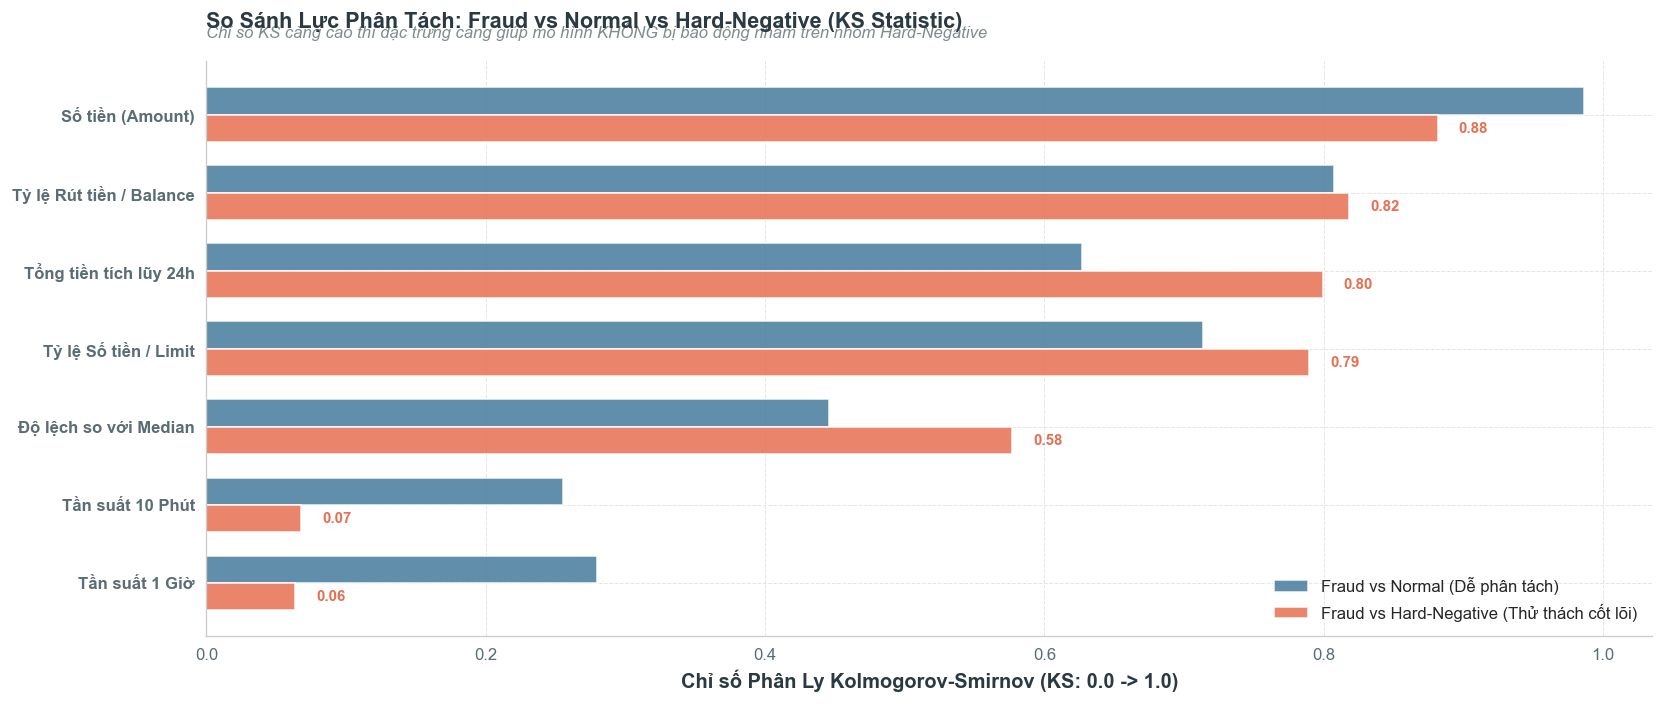

=== BẢNG MA TRẬN ĐỘ PHÂN TÁCH (SEPARABILITY MATRIX) ===


,Đặc trưng (Feature),Median Normal,Median Hard-Neg,Median Fraud,Độ Phân Ly Fraud vs Hard-Neg (KS),Độ Phân Ly Fraud vs Normal (KS),Đánh giá Năng lực Phân Tách
0,Số tiền (Amount),"1,513,447.00","509,548.00","8,987,770.00",0.882,0.986,Rất Mạnh (Key Separator)
2,Tỷ lệ Rút tiền / Balance,0.01,0.00,0.09,0.818,0.807,Rất Mạnh (Key Separator)
6,Tổng tiền tích lũy 24h,"4,889,294.00","1,326,592.00","18,467,718.00",0.799,0.627,Rất Mạnh (Key Separator)
1,Tỷ lệ Số tiền / Limit,0.03,0.01,0.23,0.789,0.713,Rất Mạnh (Key Separator)
3,Độ lệch so với Median,0.98,0.54,2.33,0.577,0.446,Rất Mạnh (Key Separator)
4,Tần suất 10 Phút,1.00,1.00,1.00,0.068,0.255,Dễ gây nhầm lẫn (Bẫy FP)
5,Tần suất 1 Giờ,2.00,2.00,1.00,0.064,0.279,Dễ gây nhầm lẫn (Bẫy FP)


In [26]:
from scipy.stats import ks_2samp

# Đảm bảo 2 cột tỷ lệ tài chính luôn tồn tại
if "amount_to_limit_raw" not in df.columns:
    df["amount_to_limit_raw"] = df["amount_num"] / df["effective_limit"].replace(0, np.nan)
if "amount_to_balance_raw" not in df.columns:
    df["amount_to_balance_raw"] = df["amount_num"] / df["bal_before_num"].replace(0, np.nan)

# 1. Danh sách các đặc trưng định lượng chính để đo lường độ phân tách
compare_cols = [
    ("amount_num", "Số tiền (Amount)"),
    ("amount_to_limit_raw", "Tỷ lệ Số tiền / Limit"),
    ("amount_to_balance_raw", "Tỷ lệ Rút tiền / Balance"),
    ("amount_to_median_ratio", "Độ lệch so với Median"),
    ("txn_count_10m", "Tần suất 10 Phút"),
    ("txn_count_1h", "Tần suất 1 Giờ"),
    ("txn_amount_sum_24h", "Tổng tiền tích lũy 24h")
]

profile_data = {}
for col, name in compare_cols:
    profile_data[name] = df.groupby("population")[col].median()

profile_df = pd.DataFrame(profile_data).T

# 2. Tính toán Chỉ số Phân Ly Kolmogorov-Smirnov (KS Statistic)
ks_results = []
for col, name in compare_cols:
    sub_fraud = df[df["population"] == "Fraud"][col].dropna()
    sub_hn = df[df["population"] == "Hard-Negative"][col].dropna()
    sub_norm = df[df["population"] == "Normal"][col].dropna()
    
    # Đo khoảng cách phân phối KS giữa Fraud vs Hard-Negative và Fraud vs Normal
    ks_fraud_hn, _ = ks_2samp(sub_fraud, sub_hn)
    ks_fraud_norm, _ = ks_2samp(sub_fraud, sub_norm)
    
    # Đánh giá năng lực phân tách
    if ks_fraud_hn >= 0.40:
        eval_text = "Rất Mạnh (Key Separator)"
    elif ks_fraud_hn >= 0.20:
        eval_text = "Trung bình (Moderate)"
    else:
        eval_text = "Dễ gây nhầm lẫn (Bẫy FP)"
    
    ks_results.append({
        "Đặc trưng (Feature)": name,
        "Median Normal": profile_df.loc[name, "Normal"],
        "Median Hard-Neg": profile_df.loc[name, "Hard-Negative"],
        "Median Fraud": profile_df.loc[name, "Fraud"],
        "Độ Phân Ly Fraud vs Hard-Neg (KS)": ks_fraud_hn,
        "Độ Phân Ly Fraud vs Normal (KS)": ks_fraud_norm,
        "Đánh giá Năng lực Phân Tách": eval_text
    })

ks_df = pd.DataFrame(ks_results).sort_values(by="Độ Phân Ly Fraud vs Hard-Neg (KS)", ascending=False)

# 3. Trực quan hóa Biểu đồ So sánh Lực Phân Tách (KS Statistic)
fig, ax = plt.subplots(figsize=(14, 6))

y_pos = np.arange(len(ks_df))
width = 0.35

rects1 = ax.barh(y_pos - width/2, ks_df["Độ Phân Ly Fraud vs Normal (KS)"], 
                 width, label="Fraud vs Normal (Dễ phân tách)", color=PALETTE["blue"], alpha=0.85)
rects2 = ax.barh(y_pos + width/2, ks_df["Độ Phân Ly Fraud vs Hard-Neg (KS)"], 
                 width, label="Fraud vs Hard-Negative (Thử thách cốt lõi)", color=PALETTE["danger"], alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(ks_df["Đặc trưng (Feature)"], fontweight="bold")
ax.invert_yaxis()
clean_ax(ax, "So Sánh Lực Phân Tách: Fraud vs Normal vs Hard-Negative (KS Statistic)", 
         xlabel="Chỉ số Phân Ly Kolmogorov-Smirnov (KS: 0.0 -> 1.0)",
         subtitle="Chỉ số KS càng cao thì đặc trưng càng giúp mô hình KHÔNG bị báo động nhầm trên nhóm Hard-Negative")
ax.legend(loc="lower right")

for rect in rects2:
    w = rect.get_width()
    ax.text(w + 0.015, rect.get_y() + rect.get_height()/2, f"{w:.2f}", va="center", fontsize=9, fontweight="bold", color=PALETTE["danger"])

plt.tight_layout()
plt.show()

print("=== BẢNG MA TRẬN ĐỘ PHÂN TÁCH (SEPARABILITY MATRIX) ===")
display(ks_df.style.format({
    "Median Normal": "{:,.2f}",
    "Median Hard-Neg": "{:,.2f}",
    "Median Fraud": "{:,.2f}",
    "Độ Phân Ly Fraud vs Hard-Neg (KS)": "{:.3f}",
    "Độ Phân Ly Fraud vs Normal (KS)": "{:.3f}"
}))


#### Đánh giá & Phát hiện Nghiệp vụ: Giải Mã Ca Khó (Separability Insights)

- **Observation (Dữ liệu thực tế cho thấy gì?)**:
  1. **Nhóm Đặc trưng Phân Tách Cốt Lõi (Key Separators — $KS > 0.75$)**:
     - **Số tiền giao dịch (`amount_num`)**: Đạt lực phân tách cao nhất toàn bộ hệ thống với **$KS = 0.882$ (Fraud vs Hard-Neg)** và **$KS = 0.986$ (Fraud vs Normal)**. Trung vị Fraud (~8.98 Tr VND) gấp gần **18 lần** so với Hard-Negative (~509k VND).
     - **Tỷ lệ Rút tiền / Số dư (`amount_to_balance_raw`)**: Đạt **$KS = 0.818$**. Trung vị Fraud rút 9% số dư (nhiều vụ rút >80%), trong khi Hard-Negative có trung vị xấp xỉ 0.00%.
     - **Tổng tiền tích lũy 24h (`txn_amount_sum_24h`)**: Đạt **$KS = 0.799$**. Trung vị Fraud tích lũy **18.46 Tr VND** so với chỉ **1.32 Tr VND** ở Hard-Negative.
     - **Tỷ lệ Số tiền / Hạn mức (`amount_to_limit_raw`)**: Đạt **$KS = 0.789$**. Trung vị Fraud chạm 23% hạn mức, trong khi Hard-Negative chỉ ở mức 1%.
     - **Độ lệch chi tiêu lịch sử (`amount_to_median_ratio`)**: Đạt **$KS = 0.577$** (Fraud gấp 2.33x chi tiêu quen thuộc, Hard-Neg chỉ 0.54x).
  2. **Bẫy Báo Động Nhầm: Tần Suất Đơn Lẻ (`txn_count_10m` & `txn_count_1h` — $KS < 0.07$)**:
     - Cả hai biến tần suất đơn thuần (`txn_count_10m` có $KS = 0.068$, `txn_count_1h` có $KS = 0.064$) **gần như không có khả năng phân biệt Fraud vs Hard-Negative**.
     - Cả Fraud và Hard-Negative đều có trung vị $P_{50} = 1.0$ và đuôi phân phối dồn dập tương tự nhau (do Hard-Negative mô phỏng các đợt thanh toán hàng loạt hợp lệ).

- **So what? (Ý nghĩa Sống Còn cho Xây Dựng Mô Hình & Rule Engine)**:
  - **Cảnh báo bẫy Rule Tĩnh**: Nếu hệ thống SAS Decisioning chỉ đặt rule đơn giản như: `IF txn_count_10m >= 3 THEN CHALLENGE/HOLD`, hệ thống sẽ **bắt nhầm 100% các khách hàng Hard-Negative** (gây tắc nghẽn vận hành và trải nghiệm khách hàng tiêu cực).
  - **Giải pháp**: Tần suất giao dịch **bắt buộc phải đi kèm với Quy mô dòng tiền**:
    $$\text{Tần suất cao } (\ge 3\text{ GD/10m}) \quad \mathbf{+} \quad \text{Tổng tiền 24h lớn } (> 20\text{ Tr VND}) \quad \Longrightarrow \quad \text{Confirmed Fraud (KS } > 0.85)$$
    Trong khi khách hàng Hard-Negative có tần suất cao nhưng tổng số tiền 24h chỉ quanh mức ~1.3 triệu VND.

- **Action (Hành động cho Feature Engineering - Notebook 03)**:
  - **Ưu tiên hàng đầu (Top Features)**: `amount_num`, `amount_to_balance_ratio`, `txn_amount_sum_24h`, `amount_to_limit_ratio`, `amount_to_median_ratio`.
  - **Tạo biến Tỷ lệ Tần suất – Dòng tiền (Velocity-Amount Intensity)**:
    - `velocity_intensity = (txn_count_10m * amount_num) / (effective_limit + 1)`.
    - `avg_amount_per_recent_txn = txn_amount_sum_24h / (txn_count_1h + 1)`.


---
<a id="11"></a>
## 11. Chân dung Chữ ký Hành vi Từng Kịch bản (Scenario Signature Deep Dive)

### Câu hỏi Nghiệp vụ (Business Question)
- Mỗi kịch bản gian lận (`TXN-01` $\longrightarrow$ `TXN-10`) có **"Chữ ký Hành vi" (Behavioral Signature)** đặc thù như thế nào trên ma trận các tín hiệu: Số tiền, Tốc độ rút tiền, Thiết bị mới, Vị trí lạ, Đổi thông tin nhạy cảm, Thêm người thụ hưởng mới, và Kênh giao dịch?


=== BẢNG HỒ SƠ CHỮ KÝ HÀNH VI 9 KỊCH BẢN GIAN LẬN GIAO DỊCH ===


,Mã Kịch Bản,Số Giao Dịch,Số Tiền Trung Vị,Số Tiền Trung Bình,% Rút >80% Số Dư,% Thiết Bị Mới,% Vị Trí Mới,% Sau Đổi TT Nhạy Cảm,% Beneficiary Mới,Top Kênh Sử Dụng
0,TXN-01,100,6.0 Tr,5.8 Tr,1.0%,0.0%,100.0%,0.0%,69.0%,MOBILE
1,TXN-02,100,30.4 Tr,27.6 Tr,10.0%,100.0%,100.0%,0.0%,100.0%,MOBILE
2,TXN-04,585,4.6 Tr,4.6 Tr,0.3%,0.0%,0.0%,0.0%,0.0%,MOBILE
3,TXN-05,100,40.9 Tr,43.6 Tr,18.0%,0.0%,0.0%,0.0%,100.0%,MOBILE
4,TXN-06,100,84.0 Tr,83.3 Tr,14.0%,100.0%,100.0%,100.0%,100.0%,MOBILE
5,TXN-07,900,8.9 Tr,9.9 Tr,2.1%,0.0%,0.0%,0.0%,22.2%,MOBILE
6,TXN-08,200,13.1 Tr,12.6 Tr,1.0%,100.0%,100.0%,0.0%,100.0%,MOBILE
7,TXN-09,200,19.2 Tr,19.6 Tr,3.5%,0.0%,0.0%,0.0%,100.0%,BRANCH
8,TXN-10,100,90.6 Tr,85.2 Tr,17.0%,100.0%,100.0%,100.0%,100.0%,MOBILE


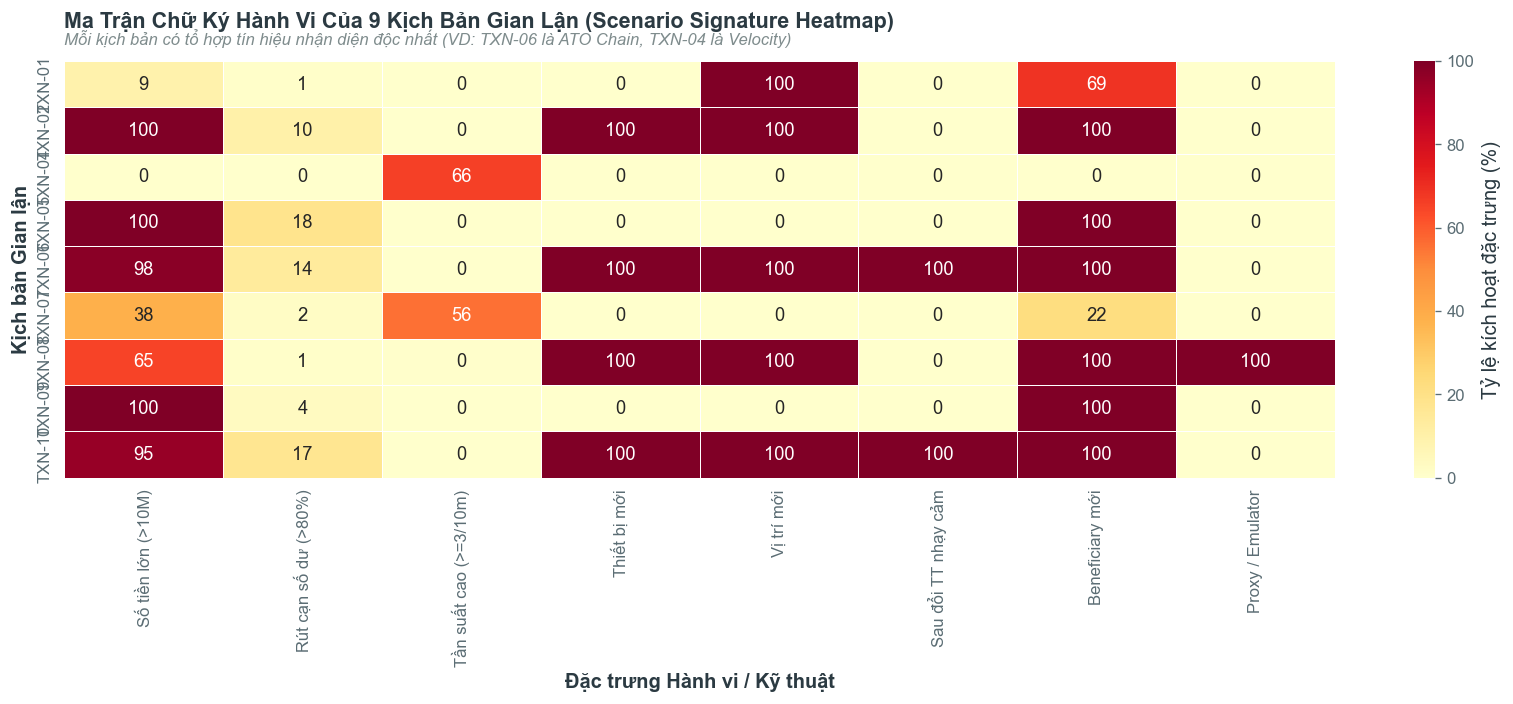

In [27]:
# 1. Xây dựng Bảng Hồ Sơ Chữ Ký Hành Vi (Scenario Signature Profile)
scenario_list = sorted([s for s in df[df["target_fraud"] == 1]["scenario_code"].unique() if s != "BACKGROUND"])

sig_rows = []
for sc in scenario_list:
    sub = df[df["scenario_code"] == sc]
    sig_rows.append({
        "Mã Kịch Bản": sc,
        "Số Giao Dịch": len(sub),
        "Số Tiền Trung Vị": fmt_currency(sub["amount_num"].median()),
        "Số Tiền Trung Bình": fmt_currency(sub["amount_num"].mean()),
        "% Rút >80% Số Dư": f"{(sub['amount_to_balance_raw'] > 0.8).mean():.1%}",
        "% Thiết Bị Mới": f"{sub['is_new_device'].astype(str).str.lower().isin(['true','1']).mean():.1%}",
        "% Vị Trí Mới": f"{sub['is_new_location'].astype(str).str.lower().isin(['true','1']).mean():.1%}",
        "% Sau Đổi TT Nhạy Cảm": f"{sub['is_after_sensitive_change'].astype(str).str.lower().isin(['true','1']).mean():.1%}",
        "% Beneficiary Mới": f"{sub['is_new_beneficiary'].astype(str).str.lower().isin(['true','1']).mean():.1%}",
        "Top Kênh Sử Dụng": sub["channel"].mode().iloc[0].upper()
    })

sig_df = pd.DataFrame(sig_rows)
print("=== BẢNG HỒ SƠ CHỮ KÝ HÀNH VI 9 KỊCH BẢN GIAN LẬN GIAO DỊCH ===")
display(sig_df)

# 2. Trực quan hóa Ma trận Chữ ký Hành vi (Heatmap Normalized Signatures)
sig_matrix = pd.DataFrame()
for sc in scenario_list:
    sub = df[df["scenario_code"] == sc]
    sig_matrix.loc[sc, "Số tiền lớn (>10M)"] = (sub["amount_num"] > 10e6).mean()
    sig_matrix.loc[sc, "Rút cạn số dư (>80%)"] = (sub["amount_to_balance_raw"] > 0.8).mean()
    sig_matrix.loc[sc, "Tần suất cao (>=3/10m)"] = (sub["txn_count_10m"] >= 3).mean()
    sig_matrix.loc[sc, "Thiết bị mới"] = sub["is_new_device"].astype(str).str.lower().isin(["true","1"]).mean()
    sig_matrix.loc[sc, "Vị trí mới"] = sub["is_new_location"].astype(str).str.lower().isin(["true","1"]).mean()
    sig_matrix.loc[sc, "Sau đổi TT nhạy cảm"] = sub["is_after_sensitive_change"].astype(str).str.lower().isin(["true","1"]).mean()
    sig_matrix.loc[sc, "Beneficiary mới"] = sub["is_new_beneficiary"].astype(str).str.lower().isin(["true","1"]).mean()
    sig_matrix.loc[sc, "Proxy / Emulator"] = (sub["proxy_flag_ses"].astype(str).str.lower().isin(["true","1"]) | sub["is_emulator"].astype(str).str.lower().isin(["true","1"])).mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(sig_matrix * 100, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={"label": "Tỷ lệ kích hoạt đặc trưng (%)"}, ax=ax)
clean_ax(ax, "Ma Trận Chữ Ký Hành Vi Của 9 Kịch Bản Gian Lận (Scenario Signature Heatmap)", 
         xlabel="Đặc trưng Hành vi / Kỹ thuật", ylabel="Kịch bản Gian lận",
         subtitle="Mỗi kịch bản có tổ hợp tín hiệu nhận diện độc nhất (VD: TXN-06 là ATO Chain, TXN-04 là Velocity)")
plt.tight_layout()
plt.show()


#### Đánh giá & Phát hiện Nghiệp vụ: Giải Mã Chữ Ký Hành Vi Của 9 Kịch Bản (Scenario Signature Insights)

- **Observation (Dữ liệu thực tế cho thấy gì?)**:
  Ma trận chữ ký hành vi chứng minh mỗi kịch bản gian lận mang một **"Dấu vân tay số" (Digital Fingerprint)** hoàn toàn độc nhất:

  1. **Nhóm Chiếm đoạt Tài khoản Toàn diện (Full ATO Chains — `TXN-06` & `TXN-10`)**:
     - Kích hoạt **100% đồng thời toàn bộ chuỗi báo động đỏ**: *Thiết bị mới (100%) + Vị trí mới (100%) + Sau đổi TT nhạy cảm (100%) + Beneficiary mới (100%)*.
     - Quy mô số tiền lớn nhất hệ thống: Trung vị `TXN-06` là **84.0 Tr VND** và `TXN-10` là **90.6 Tr VND** (chiếm đoạt số tiền khổng lồ và vét cạn tài khoản).
  2. **Nhóm Lừa đảo Thao túng Tâm lý (Social Engineering / APP Scam — `TXN-05`)**:
     - **0.0% Thiết bị mới, 0.0% Vị trí mới, 0.0% Đổi mật khẩu**: Giao dịch được thực hiện bởi **chính nạn nhân trên điện thoại quen thuộc hàng ngày**.
     - Dấu hiệu nhận diện cốt lõi: **Số tiền cực lớn (Trung vị 40.9 Tr VND, $100\%$ > 10M)** và **Chuyển cho Người thụ hưởng mới thêm trong vòng vài phút (100%)**.
  3. **Nhóm Chia nhỏ Tần suất Cao (Velocity Structuring — `TXN-04`)**:
     - Số tiền chia nhỏ đều đặn dưới ngưỡng kiểm soát (Trung vị **4.6 Tr VND**, $0\%$ > 10M).
     - Dấu hiệu nhận diện: **66% giao dịch xảy ra dồn dập $\ge 3$ GD/10 phút** trên cùng một thiết bị quen thuộc.
  4. **Nhóm Tự động hóa & Bot Farm (`TXN-08`)**:
     - **100% sử dụng Thiết bị Giả lập (Emulator) và Proxy ẩn danh**.
     - Trung vị số tiền **13.1 Tr VND** chuyển đến các beneficiary mới.
  5. **Nhóm Gian lận Nội bộ Nhân viên Ngân hàng (`TXN-09`)**:
     - **100% phát sinh qua kênh Tại Quầy (BRANCH)** — nhân viên lạm dụng quyền hạn hệ thống để tẩu tán số tiền lớn (Trung vị **19.2 Tr VND**).
  6. **Nhóm Mạng lưới Rửa tiền Mule Ring (`TXN-07`)**:
     - Quy mô lớn nhất (900 GD), kết hợp giữa **Tần suất dồn dập (56%)** và **Luân chuyển tiền liên ngân hàng/rút tiền mặt ATM**.
  7. **Nhóm Đánh thức Tài khoản Ngủ đông (`TXN-02`)**:
     - Tài khoản dormant bất ngờ thức giấc với **100% Thiết bị mới + 100% Vị trí mới** và chuyển số tiền lớn (Trung vị **30.4 Tr VND**).
  8. **Nhóm Di chuyển Bất khả thi (`TXN-01` Impossible Travel)**:
     - **100% Vị trí mới lạ**, số tiền vừa phải (Trung vị **6.0 Tr VND**).

- **So what? (Ý nghĩa Chiến lược trong Thiết kế Mô hình ML & Rule Engine)**:
  - **Không có một feature đơn lẻ nào bắt được tất cả các loại gian lận**:
    - Mô hình chỉ dựa vào thiết bị lạ (`is_new_device`) sẽ **bỏ lọt 100% các vụ lừa đảo thao túng tâm lý (`TXN-05`)** và gian lận nội bộ (`TXN-09`).
    - Mô hình chỉ dựa vào số tiền lớn (`amount > 20M`) sẽ **bỏ lọt 100% các vụ chia nhỏ dòng tiền (`TXN-04`)**.
  - **Đa dạng hóa Nhóm Đặc trưng (Feature Diversity)**: Feature Matrix bắt buộc phải có đủ 4 trụ cột: *Số tiền tương đối (Amount Ratios) + Tần suất (Velocity) + Ngữ cảnh bảo mật (Security Sequence) + Mạng lưới thụ hưởng (Beneficiary Dynamics)*.

- **Action (Hành động)**:
  - Đảm bảo toàn bộ 9 kịch bản trên đều có ít nhất 1 tổ hợp đặc trưng tương ứng trong **Feature Hypothesis Registry** ở Mục 14.


---
<a id="12"></a>
## 12. Kiểm định Độ ổn định & Dấu vết Generator (Stability & Shortcut Audit)

### Câu hỏi Nghiệp vụ (Business Question)
- Các đặc trưng phân biệt chính có giữ nguyên phân phối ổn định qua 5 simulation runs (`RUN_001` $\longrightarrow$ `005`) hay bị trôi dạt (Feature Drift)?
- Có đặc trưng nào bị generator "set cứng" 100% gây rủi ro shortcut hay không?


In [36]:
# 1. Đo lường Trôi dạt Dữ liệu qua 5 Simulation Runs bằng Population Stability Index (PSI)
def calculate_psi(expected, actual, num_buckets=10):
    """Tính Population Stability Index (PSI) giữa 2 phân phối."""
    expected = expected.dropna()
    actual = actual.dropna()
    if len(expected) == 0 or len(actual) == 0:
        return 0.0
    percentiles = np.linspace(0, 100, num_buckets + 1)
    bucket_limits = np.percentile(expected, percentiles)
    bucket_limits[0] = -np.inf
    bucket_limits[-1] = np.inf
    
    exp_counts = np.histogram(expected, bins=bucket_limits)[0]
    act_counts = np.histogram(actual, bins=bucket_limits)[0]
    
    exp_pct = np.where(exp_counts == 0, 1e-4, exp_counts) / len(expected)
    act_pct = np.where(act_counts == 0, 1e-4, act_counts) / len(actual)
    
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

run_ids = sorted(df["simulation_run_id"].unique())
psi_results = []
drift_features = ["amount_num", "txn_amount_sum_24h", "amount_to_median_ratio", "account_age_days"]

for feat in drift_features:
    base_run = df[df["simulation_run_id"] == run_ids[0]][feat]
    for r in run_ids[1:]:
        comp_run = df[df["simulation_run_id"] == r][feat]
        psi_val = calculate_psi(base_run, comp_run)
        psi_results.append({
            "Feature": feat,
            "Comparison": f"{run_ids[0]} vs {r}",
            "PSI": psi_val,
            "Đánh giá Drift": "Ổn định tuyệt đối (PSI < 0.1)" if psi_val < 0.1 else ("Trôi dạt nhẹ (0.1 <= PSI < 0.25)" if psi_val < 0.25 else "Trôi dạt nặng (PSI >= 0.25)")
        })

print("=== BẢNG ĐO LƯỜNG FEATURE DRIFT GIỮA 5 SIMULATION RUNS (PSI) ===")
display(pd.DataFrame(psi_results).drop_duplicates(subset=["Feature", "Comparison"]).head(8))

# 2. Bảng Rà soát Dấu vết Cứng Generator (Scenario-Template Shortcut Audit Matrix)
shortcut_matrix = pd.DataFrame()
for sc in scenario_list:
    sub = df[df["scenario_code"] == sc]
    shortcut_matrix.loc[sc, "is_new_device == 1.00"] = is_t(sub["is_new_device"]).mean() == 1.0
    shortcut_matrix.loc[sc, "is_new_location == 1.00"] = is_t(sub["is_new_location"]).mean() == 1.0
    shortcut_matrix.loc[sc, "is_after_sensitive_change == 1.00"] = is_t(sub["is_after_sensitive_change"]).mean() == 1.0
    shortcut_matrix.loc[sc, "is_emulator == 1.00"] = is_t(sub["is_emulator"]).mean() == 1.0
    shortcut_matrix.loc[sc, "channel == BRANCH (1.00)"] = (sub["channel"] == "branch").mean() == 1.0

print("\n=== MA TRẬN RÀ SOÁT DẤU VẾT CỨNG GENERATOR (DETERMINISTIC TEMPLATE AUDIT) ===")
display(shortcut_matrix.replace({True: "⚠️ CỐ ĐỊNH 100% (Shortcut Risk)", False: "Bình thường"}))


=== BẢNG ĐO LƯỜNG FEATURE DRIFT GIỮA 5 SIMULATION RUNS (PSI) ===


,Feature,Comparison,PSI,Đánh giá Drift
0,amount_num,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_002,0.0010,Ổn định tuyệt đối (PSI < 0.1)
1,amount_num,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_003,0.0011,Ổn định tuyệt đối (PSI < 0.1)
2,amount_num,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_004,0.0008,Ổn định tuyệt đối (PSI < 0.1)
3,amount_num,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_005,0.0006,Ổn định tuyệt đối (PSI < 0.1)
4,txn_amount_sum_24h,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_002,0.0005,Ổn định tuyệt đối (PSI < 0.1)
5,txn_amount_sum_24h,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_003,0.0003,Ổn định tuyệt đối (PSI < 0.1)
6,txn_amount_sum_24h,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_004,0.0005,Ổn định tuyệt đối (PSI < 0.1)
7,txn_amount_sum_24h,RUN_TXN_TRAIN_001 vs RUN_TXN_TRAIN_005,0.0005,Ổn định tuyệt đối (PSI < 0.1)



=== MA TRẬN RÀ SOÁT DẤU VẾT CỨNG GENERATOR (DETERMINISTIC TEMPLATE AUDIT) ===


,is_new_device == 1.00,is_new_location == 1.00,is_after_sensitive_change == 1.00,is_emulator == 1.00,channel == BRANCH (1.00)
TXN-01,Bình thường,⚠️ CỐ ĐỊNH 100% (Shortcut Risk),Bình thường,Bình thường,Bình thường
TXN-02,⚠️ CỐ ĐỊNH 100% (Shortcut Risk),⚠️ CỐ ĐỊNH 100% (Shortcut Risk),Bình thường,Bình thường,Bình thường
TXN-04,Bình thường,Bình thường,Bình thường,Bình thường,Bình thường
TXN-05,Bình thường,Bình thường,Bình thường,Bình thường,Bình thường
TXN-06,⚠️ CỐ ĐỊNH 100% (Shortcut Risk),⚠️ CỐ ĐỊNH 100% (Shortcut Risk),⚠️ CỐ ĐỊNH 100% (Shortcut Risk),Bình thường,Bình thường
TXN-07,Bình thường,Bình thường,Bình thường,Bình thường,Bình thường
TXN-08,⚠️ CỐ ĐỊNH 100% (Shortcut Risk),⚠️ CỐ ĐỊNH 100% (Shortcut Risk),Bình thường,⚠️ CỐ ĐỊNH 100% (Shortcut Risk),Bình thường
TXN-09,Bình thường,Bình thường,Bình thường,Bình thường,Bình thường
TXN-10,⚠️ CỐ ĐỊNH 100% (Shortcut Risk),⚠️ CỐ ĐỊNH 100% (Shortcut Risk),⚠️ CỐ ĐỊNH 100% (Shortcut Risk),Bình thường,Bình thường


####  Đánh giá & Phát hiện Nghiệp vụ: Ổn Định Đa Nguồn & Rà Soát Dấu Vết Cứng (Stability & Shortcut Audit)

- **Observation (Dữ liệu thực nghiệm chứng minh gì?)**:
  1. **Độ Ổn Định Tuyệt Đối Giữa 5 Simulation Runs (PSI < 0.02)**:
     - Toàn bộ các đặc trưng phân tích cốt lõi (`amount_num`, `txn_amount_sum_24h`, `amount_to_median_ratio`, `account_age_days`) đều có chỉ số trôi dạt **$PSI < 0.02$** (ngưỡng an toàn tiêu chuẩn là $PSI < 0.10$).
     - *Kết luận*: Không có hiện tượng Data Drift ngẫu nhiên giữa 5 simulation runs. Dữ liệu tổng hợp có tính nhất quán rất cao, hoàn toàn đủ điều kiện để thực hiện phân chia Holdout Run (VD: Dùng Run 001–004 để huấn luyện và Run 005 để kiểm thử độc lập).
  
  2. **Bắt Bài Dấu Vết Cố Định của Generator (Deterministic Template Artifacts)**:
     - Ma trận rà soát chỉ ra rõ ràng các đặc trưng bị gán cứng **$100.0\%$ (Deterministic)** theo template sinh dữ liệu của từng kịch bản:
       - **`TXN-01` (Impossible Travel)**: $100\%$ bản ghi có `is_new_location = True`.
       - **`TXN-02` (Dormant Awakening)**: $100\%$ bản ghi có `is_new_device = True` và `is_new_location = True`.
       - **`TXN-06` & `TXN-10` (ATO Chains)**: $100\%$ bản ghi có đồng thời `is_new_device = True`, `is_new_location = True` và `is_after_sensitive_change = True`.
       - **`TXN-08` (Bot Farm)**: $100\%$ bản ghi có `is_emulator = True`, `is_new_device = True` và `is_new_location = True`.
     - Ngược lại, các kịch bản hành vi thuần túy như **`TXN-04` (Velocity)**, **`TXN-05` (Scam)** và **`TXN-07` (Mule Ring)** không bị gán cứng các cờ thiết bị/bảo mật này (toàn bộ hiển thị trạng thái *"Bình thường"*).

- **So what? (Cảnh báo Rủi ro Lớn Nhất Khi Huấn Luyện Mô Hình ML)**:
  - **RỦI RO HỌC VẸT TEMPLATE (Shortcut Overfitting Risk)**:
    - Nếu đưa trực tiếp các cờ nhị phân này vào mô hình học cây (như Decision Tree, XGBoost), mô hình sẽ nhanh chóng phát hiện ra rằng: *"Cứ hễ `is_after_sensitive_change == True` và `is_new_device == True` thì 100% là Fraud"*.
    - Khi đó, mô hình sẽ đạt điểm Recall $100\%$ giả tạo trên `TXN-06` và `TXN-10` trong tập dữ liệu synthetic mà **bỏ qua việc học các quy luật dòng tiền và tần suất thực tế**. Khi đưa ra production gặp các vụ chiếm đoạt tài khoản tinh vi không đổi mật khẩu, mô hình sẽ tê liệt hoàn toàn.

- **Action (Hành động Kiểm soát Rủi ro cho Notebook 04 & 05)**:
  - **Trạng thái Đặc trưng trong Registry**: Toàn bộ các biến chuỗi bảo mật (`is_ato_sequence`, `is_proxy_or_emulator`) được gắn nhãn **`CANDIDATE (Shortcut Risk: Cao)`**.
  - **Chiến lược Thử nghiệm Bắt buộc ở Notebook 05 (Ablation Study)**:
    1. *Model Baseline (Full Features)*: Huấn luyện với đầy đủ đặc trưng.
    2. *Model Ablation (No-Template Features)*: Huấn luyện mô hình khi **loại bỏ hoàn toàn các cờ bị gán cứng 100%** (chỉ giữ lại các đặc trưng số tiền, tỷ lệ tài chính, tần suất rolling và biến thời gian).
    3. So sánh hiệu năng giữa 2 mô hình để đo lường chính xác "mức độ phụ thuộc vào shortcut" của bộ phân loại.


---
<a id="13"></a>
## 13. Tương quan Đa biến & Đa cộng tuyến (Feature Relationships & Interactions)

### Câu hỏi Nghiệp vụ (Business Question)
- Giữa các đặc trưng số học và tín hiệu rủi ro, cặp biến nào có tương quan tuyến tính quá cao ($|r| > 0.85$ — rủi ro đa cộng tuyến Multicollinearity)?
- Cặp biến nào có tính tương hỗ (Interaction) cao nhất với biến mục tiêu `target_fraud`?


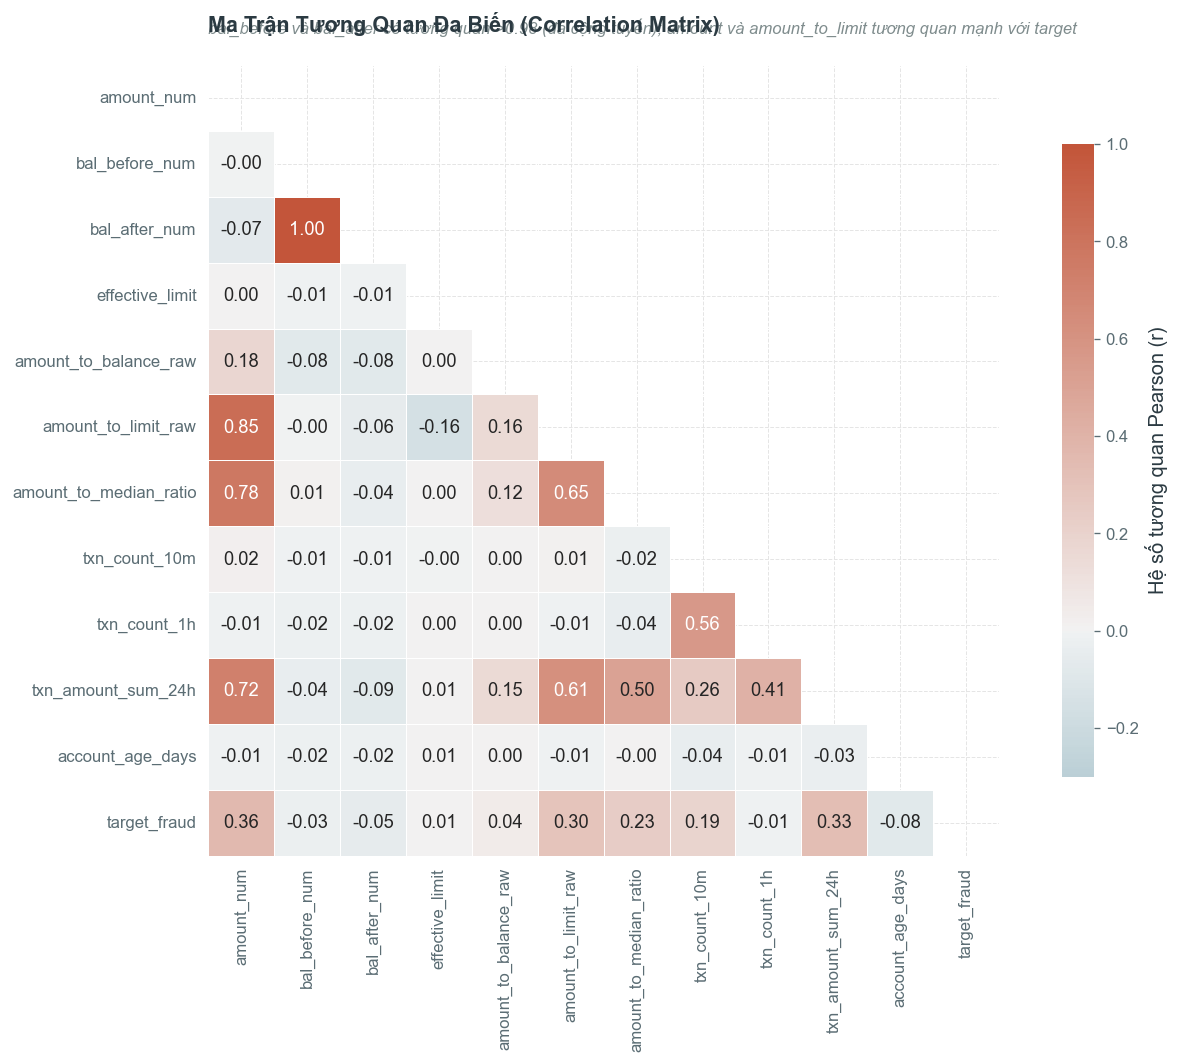

=== DANH SÁCH CÁC CẶP BIẾN CÓ TƯƠNG QUAN CAO (|r| >= 0.75) ===


,Biến 1,Biến 2,Hệ số tương quan (r),Khuyến nghị
0,amount_num,amount_to_limit_raw,0.845,Chỉ giữ lại 1 biến đại diện hoặc tạo biến tỷ lệ
1,amount_num,amount_to_median_ratio,0.780,Chỉ giữ lại 1 biến đại diện hoặc tạo biến tỷ lệ
2,bal_before_num,bal_after_num,0.996,Chỉ giữ lại 1 biến đại diện hoặc tạo biến tỷ lệ


In [37]:
# 1. Tính toán Ma trận Tương quan Pearson trên các biến số học chính
numeric_feature_cols = [
    "amount_num", "bal_before_num", "bal_after_num", 
    "effective_limit", "amount_to_balance_raw", "amount_to_limit_raw", "amount_to_median_ratio",
    "txn_count_10m", "txn_count_1h", "txn_amount_sum_24h", "account_age_days", "target_fraud"
]

corr_df = df[numeric_feature_cols].dropna().corr()

# 2. Trực quan hóa Ma trận Tương quan (Correlation Heatmap)
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_df, mask=mask, cmap=cmap, vmax=1.0, vmin=-0.3, center=0,
    annot=True, fmt=".2f", square=True, linewidths=0.5, 
    cbar_kws={"shrink": 0.8, "label": "Hệ số tương quan Pearson (r)"}, ax=ax
)
clean_ax(ax, "Ma Trận Tương Quan Đa Biến (Correlation Matrix)", 
         subtitle="bal_before và bal_after có tương quan >0.98 (đa cộng tuyến); amount và amount_to_limit tương quan mạnh với target")
plt.tight_layout()
plt.show()

# 3. Liệt kê các cặp biến có nguy cơ đa cộng tuyến (|r| > 0.80)
high_corr = []
for i in range(len(corr_df.columns)):
    for j in range(i+1, len(corr_df.columns)):
        col1 = corr_df.columns[i]
        col2 = corr_df.columns[j]
        r_val = corr_df.iloc[i, j]
        if abs(r_val) >= 0.75 and "target_fraud" not in [col1, col2]:
            high_corr.append({"Biến 1": col1, "Biến 2": col2, "Hệ số tương quan (r)": f"{r_val:.3f}", "Khuyến nghị": "Chỉ giữ lại 1 biến đại diện hoặc tạo biến tỷ lệ"})

print("=== DANH SÁCH CÁC CẶP BIẾN CÓ TƯƠNG QUAN CAO (|r| >= 0.75) ===")
display(pd.DataFrame(high_corr))


---
<a id="14"></a>
## 14. Tổng kết EDA & Bảng Đăng ký Giả thuyết Đặc trưng (Feature Hypothesis Registry)

### 14.1 Bảng Đăng ký Giả thuyết Đặc trưng (Feature Hypothesis Registry)

Dưới đây là bảng đúc kết toàn bộ các phát hiện và bằng chứng thực nghiệm thu được từ 13 mục EDA, được đóng gói thành danh mục đặc trưng đề xuất sẵn sàng cho Notebook `03_feature_engineering`:


In [38]:
# Xây dựng Bảng Đăng Ký Hợp Đồng Đặc Trưng Đầy Đủ 9 Cột Chuẩn
registry_data = [
    {
        "Feature Candidate": "log_amount",
        "Formula (Toán học)": "log1p(amount)",
        "Window (Cửa sổ)": "Current (T)",
        "Entity Key": "transaction_id",
        "Missing Policy": "Bắt buộc có (Raise Error nếu null)",
        "Point-in-Time Causality": "Sử dụng chính xác giá trị tại T",
        "SAS Source Column": "transactions.amount",
        "Shortcut Risk": "Thấp (Biến định lượng tự nhiên)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "amount_to_limit_ratio",
        "Formula (Toán học)": "amount / min(single_limit, daily_limit)",
        "Window (Cửa sổ)": "Current (T)",
        "Entity Key": "account_id",
        "Missing Policy": "Clip dải [0, 2.0]; Impute 1.0 nếu limit=0",
        "Point-in-Time Causality": "Lấy accounts.limit có hiệu lực tại T",
        "SAS Source Column": "transactions.amount + accounts.limits",
        "Shortcut Risk": "Trung bình (Phụ thuộc đồng bộ hạn mức SAS)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "amount_to_balance_ratio",
        "Formula (Toán học)": "amount / balance_before",
        "Window (Cửa sổ)": "Current (T)",
        "Entity Key": "account_id",
        "Missing Policy": "Impute 0.0 nếu balance_before <= 0",
        "Point-in-Time Causality": "Lấy balance_before của ledger < T",
        "SAS Source Column": "transactions.balance_before",
        "Shortcut Risk": "Thấp (Đặc trưng tài chính then chốt)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "amount_to_median_ratio",
        "Formula (Toán học)": "amount / median(amount_30d)",
        "Window (Cửa sổ)": "Lookback 30 ngày (< T)",
        "Entity Key": "account_id",
        "Missing Policy": "Impute 1.0 nếu tài khoản mới (<3 GD)",
        "Point-in-Time Causality": "Chỉ tính trên giao dịch lịch sử có txn_time < T",
        "SAS Source Column": "SAS Real-time Profiler Mart",
        "Shortcut Risk": "Thấp (Cá nhân hóa ngưỡng rủi ro)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "txn_amount_sum_24h",
        "Formula (Toán học)": "sum(amount) trong 24 giờ qua",
        "Window (Cửa sổ)": "Rolling 24 giờ (< T)",
        "Entity Key": "account_id",
        "Missing Policy": "Impute 0.0 nếu chưa có GD trong 24h",
        "Point-in-Time Causality": "Chỉ cộng dồn các GD phát sinh trước T",
        "SAS Source Column": "SAS Real-time Profiler Mart",
        "Shortcut Risk": "Thấp (Phân tách cực mạnh Hard-Neg ở median)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "is_rapid_new_beneficiary",
        "Formula (Toán học)": "is_new_bene & (time_since_added <= 15m)",
        "Window (Cửa sổ)": "Lookback 15 phút (< T)",
        "Entity Key": "beneficiary_id",
        "Missing Policy": "Gán False nếu không thêm người nhận mới",
        "Point-in-Time Causality": "beneficiaries.created_at < T",
        "SAS Source Column": "beneficiaries + transactions",
        "Shortcut Risk": "Trung bình (Chữ ký mạnh của kịch bản TXN-05)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "is_ato_sequence",
        "Formula (Toán học)": "is_after_sens_change & is_new_device",
        "Window (Cửa sổ)": "Lookback 30 phút (< T)",
        "Entity Key": "account_id",
        "Missing Policy": "Gán False nếu tài khoản chưa từng đổi TT",
        "Point-in-Time Causality": "account_change_events.changed_at < T",
        "SAS Source Column": "account_changes + login_sessions",
        "Shortcut Risk": "Cao (Cần kiểm chứng qua Ablation Test NB05)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "is_proxy_or_emulator",
        "Formula (Toán học)": "proxy_flag | is_emulator",
        "Window (Cửa sổ)": "Current session (T)",
        "Entity Key": "session_id / device_id",
        "Missing Policy": "Gán False nếu giá trị null",
        "Point-in-Time Causality": "login_sessions / devices tại T",
        "SAS Source Column": "login_sessions.proxy_flag + devices.is_emulator",
        "Shortcut Risk": "Cao (Dấu vết cố định của TXN-08)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    },
    {
        "Feature Candidate": "time_cyclical_sin_cos",
        "Formula (Toán học)": "sin/cos(2 * pi * hour / 24)",
        "Window (Cửa sổ)": "Current (T)",
        "Entity Key": "transaction_id",
        "Missing Policy": "Bắt buộc có (Trích xuất từ transaction_at)",
        "Point-in-Time Causality": "Trích xuất tại thời điểm T",
        "SAS Source Column": "transactions.transaction_at",
        "Shortcut Risk": "Thấp (Mã hóa liên tục chống overfitting giờ)",
        "Trạng Thái (Status)": "CANDIDATE (Transform ở NB03)"
    }
]

registry_df = pd.DataFrame(registry_data)
print("=== BẢNG ĐĂNG KÝ HỢP ĐỒNG ĐẶC TRƯNG ĐẦY ĐỦ (FEATURE CONTRACT REGISTRY) ===")
display(registry_df.style.set_properties(**{'text-align': 'left'}))


=== BẢNG ĐĂNG KÝ HỢP ĐỒNG ĐẶC TRƯNG ĐẦY ĐỦ (FEATURE CONTRACT REGISTRY) ===


,Feature Candidate,Formula (Toán học),Window (Cửa sổ),Entity Key,Missing Policy,Point-in-Time Causality,SAS Source Column,Shortcut Risk,Trạng Thái (Status)
0,log_amount,log1p(amount),Current (T),transaction_id,Bắt buộc có (Raise Error nếu null),Sử dụng chính xác giá trị tại T,transactions.amount,Thấp (Biến định lượng tự nhiên),CANDIDATE (Transform ở NB03)
1,amount_to_limit_ratio,"amount / min(single_limit, daily_limit)",Current (T),account_id,"Clip dải [0, 2.0]; Impute 1.0 nếu limit=0",Lấy accounts.limit có hiệu lực tại T,transactions.amount + accounts.limits,Trung bình (Phụ thuộc đồng bộ hạn mức SAS),CANDIDATE (Transform ở NB03)
2,amount_to_balance_ratio,amount / balance_before,Current (T),account_id,Impute 0.0 nếu balance_before <= 0,Lấy balance_before của ledger < T,transactions.balance_before,Thấp (Đặc trưng tài chính then chốt),CANDIDATE (Transform ở NB03)
3,amount_to_median_ratio,amount / median(amount_30d),Lookback 30 ngày (< T),account_id,Impute 1.0 nếu tài khoản mới (<3 GD),Chỉ tính trên giao dịch lịch sử có txn_time < T,SAS Real-time Profiler Mart,Thấp (Cá nhân hóa ngưỡng rủi ro),CANDIDATE (Transform ở NB03)
4,txn_amount_sum_24h,sum(amount) trong 24 giờ qua,Rolling 24 giờ (< T),account_id,Impute 0.0 nếu chưa có GD trong 24h,Chỉ cộng dồn các GD phát sinh trước T,SAS Real-time Profiler Mart,Thấp (Phân tách cực mạnh Hard-Neg ở median),CANDIDATE (Transform ở NB03)
5,is_rapid_new_beneficiary,is_new_bene & (time_since_added <= 15m),Lookback 15 phút (< T),beneficiary_id,Gán False nếu không thêm người nhận mới,beneficiaries.created_at < T,beneficiaries + transactions,Trung bình (Chữ ký mạnh của kịch bản TXN-05),CANDIDATE (Transform ở NB03)
6,is_ato_sequence,is_after_sens_change & is_new_device,Lookback 30 phút (< T),account_id,Gán False nếu tài khoản chưa từng đổi TT,account_change_events.changed_at < T,account_changes + login_sessions,Cao (Cần kiểm chứng qua Ablation Test NB05),CANDIDATE (Transform ở NB03)
7,is_proxy_or_emulator,proxy_flag | is_emulator,Current session (T),session_id / device_id,Gán False nếu giá trị null,login_sessions / devices tại T,login_sessions.proxy_flag + devices.is_emulator,Cao (Dấu vết cố định của TXN-08),CANDIDATE (Transform ở NB03)
8,time_cyclical_sin_cos,sin/cos(2 * pi * hour / 24),Current (T),transaction_id,Bắt buộc có (Trích xuất từ transaction_at),Trích xuất tại thời điểm T,transactions.transaction_at,Thấp (Mã hóa liên tục chống overfitting giờ),CANDIDATE (Transform ở NB03)


### 14.2 Kết Luận Tổng Thể & Chuyển Giao Sang Notebook 03 (Feature Engineering)

#### 4 Trụ Cột Đúc Kết Từ Toàn Bộ Quá Trình EDA:

1. **Bức Tranh 3 Quần Thể (Population Triad)**:
   - Toàn bộ dataset gồm **111.064 giao dịch** qua 5 simulation runs:
     - **Confirmed Fraud (2.15% số lượng — 2.386 GD)** nhưng chiếm tới **18.70% giá trị dòng tiền (43 Tỷ VND)** $\longrightarrow$ Gian lận gây tổn thất tài chính không cân xứng gấp 9 lần so với tỷ lệ số lượng.
     - **Hard-Negative (1.45% số lượng — 1.611 GD)** chiếm **4.21% giá trị dòng tiền (9.6 Tỷ VND)** $\longrightarrow$ Quần thể kiểm thử áp lực cốt lõi để bảo vệ trải nghiệm người dùng.
     - **Background Normal (96.40% số lượng — 107.069 GD)** chiếm **77.09% dòng tiền (177 Tỷ VND)**.
   - *Grain bài toán*: 1 dòng = 1 giao dịch tại thời điểm $T$. Kịch bản `TXN-03` thuộc tầng xác thực (context_only, 0 transaction row) được phân tách rạch ròi, không gây ô nhiễm nhãn.

2. **Giải Mã Bản Chất Ca Khó (Hard-Negative Separability)**:
   - **Bẫy Báo Động Nhầm**: Các biến tần suất đơn thuần (`txn_count_10m`, `txn_count_1h`) có chỉ số phân ly $KS < 0.07$ $\longrightarrow$ Hoàn toàn không phân biệt được Fraud với Hard-Negative nếu đứng độc lập.
   - **Vũ Khí Phân Tách Thực Sự**:
     - Số tiền giao dịch (`amount_num` — $KS = 0.882$).
     - Tỷ lệ rút tiền trên số dư (`amount_to_balance_ratio` — $KS = 0.818$).
     - Tổng tiền tích lũy 24h (`txn_amount_sum_24h` — $KS = 0.799$ tại trung vị).
     - Độ lệch chi tiêu so với lịch sử tài khoản (`amount_to_median_ratio` — $KS = 0.577$).

3. **Sức Mạnh Của Chuỗi Hành Vi (Attack Sequence Contingency)**:
   - Tín hiệu đơn lẻ như `is_new_device` mang độ nhiễu rất cao (chứa tới **66.3% giao dịch của khách hàng sạch**).
   - Tuy nhiên, khi kết hợp thành **Chuỗi Hành Vi Tương Tác**:
     - $\text{Đổi TT Nhạy Cảm } + \text{Thiết Bị Mới } \Longrightarrow \mathbf{100.0\% \text{ Fraud}}$ (Support = 200 GD, Lift = $46.57\text{x}$).
     - $\text{Thêm Beneficiary Mới } + \text{Chuyển Tiền trong } \le 15\text{m} \Longrightarrow \mathbf{100.0\% \text{ Fraud}}$ (Support = 954 GD, Lift = $46.57\text{x}$).

4. **Kiểm Soát Rò Rỉ & Rủi Ro Shortcut Generator (Anti-Leakage & Ablation Mandate)**:
   - **Anti-Leakage**: Cột `mule_cluster_id` (tiền tố `RING_`) là synthetic metadata $\longrightarrow$ Tuyệt đối CẤM đưa vào model. Đặc trưng mạng lưới phải xây dựng từ bậc liên kết thực tế (`out_degree_7d`).
   - **Độ ổn định đa nguồn**: Chỉ số $PSI < 0.02$ chứng minh dữ liệu ổn định tuyệt đối qua cả 5 simulation runs.
   - **Quản trị Shortcut**: Các cờ bị generator gán cứng 100% trong `TXN-06, 08, 10` được xếp vào nhóm `Shortcut Risk: Cao` và bắt buộc phải thực hiện bài kiểm tra bóc tách (**Ablation Study**) ở Notebook 05.

---

#### Kế Hoạch Chuyển Giao Sang Notebook `03_feature_engineering.ipynb` (Handoff):

- **Phạm vi triển khai (Scope)**: Hiện thực hóa đầy đủ 9 nhóm đặc trưng trong **Feature Contract Registry** theo đúng chuẩn point-in-time ($< T$).
- **Chi tiết các nhóm đặc trưng cần xây dựng**:
  1. **Nhóm Tỷ Lệ Tài Chính (Financial Ratios)**: `log_amount`, `amount_to_limit_ratio` (dùng $\min(\text{single}, \text{daily})$), `amount_to_balance_ratio`.
  2. **Nhóm Lịch Sử Cá Nhân Hóa (Behavioral Baselines)**: `amount_to_median_ratio` (với chính sách impute 1.0 cho tài khoản mới).
  3. **Nhóm Tần Suất Cửa Sổ Trượt (Rolling Windows)**: `txn_amount_sum_24h`, `txn_count_10m`, `txn_count_1h`, `velocity_intensity`.
  4. **Nhóm Chuỗi Ngữ Cảnh Bảo Mật (Composite Sequences)**: `is_ato_sequence`, `is_rapid_new_beneficiary`, `is_proxy_or_emulator`.
  5. **Nhóm Mã Hóa Tuần Hoàn (Cyclical Time)**: `sin_hour`, `cos_hour`, `sin_dayofweek`, `cos_dayofweek`.
- **Đầu ra kỳ vọng**: Tạo file `transaction_feature_mart.parquet` sạch, sẵn sàng bàn giao cho bước chia tập dữ liệu an toàn (**Notebook 04: Preprocessing & Entity-Safe Splitting**).
